In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "configs").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import yaml
import pandas as pd
import numpy as np

import torch
from model import LightningWBoson
from physics.diagnostics import component_calibration
from physics.torchBoost import Booster as TorchBooster
from physics.physics import dphi as dphi
from physics.physics import sphi as sphi
from train import train

from matplotlib import pyplot as plt
from notebooks.plottingtool import (
    plot_1d_hist,
    plot_2d_hist,
    plot_2d_res_hist,
    plot_angular_1d_grid,
    plot_angular_2d_grid,
    plot_loss_curves,
    plot_gradient_cosine_heatmaps,
)

import mplhep as hep
hep.style.use("ATLAS")


In [2]:
CONFIG_PATH = REPO_ROOT / "configs/config.yaml"
with CONFIG_PATH.open() as file:
    cfg = yaml.safe_load(file)

# Visualize the configured training output, selecting the "best" checkpoint (by monitor
# metric) or the "latest" (newest epoch checkpoint) via CKPT_SELECTION below.
CKPT_SELECTION = "best"
RUN_DIR = Path(cfg["paths"]["saved_path"]).expanduser()
if not RUN_DIR.is_absolute():
    RUN_DIR = (REPO_ROOT / RUN_DIR).resolve()

log_dirs = sorted((RUN_DIR / "logs").glob("version_*"), key=lambda path: path.stat().st_mtime, reverse=True)
ckpt_files = sorted((RUN_DIR / "logs").glob("version_*/checkpoints/*.ckpt"), key=lambda path: path.stat().st_mtime, reverse=True)
print(f"Training run directory: {RUN_DIR}")
print(f"Found log directories: {[str(path) for path in log_dirs]}")
print(f"Found checkpoint files: {[str(path) for path in ckpt_files]}")
if not ckpt_files:
    raise FileNotFoundError(f"No checkpoint files found under {RUN_DIR}")

ranked_ckpts = [path for path in ckpt_files if path.name != "last.ckpt"] or ckpt_files
if CKPT_SELECTION == "latest":
    ckpt_path = next((path for path in ckpt_files if path.name == "last.ckpt"), ranked_ckpts[0])
    print(f"Using most recent checkpoint: {ckpt_path}")
elif CKPT_SELECTION == "best":
    trainer_cfg = cfg.get("trainer", {})
    monitor_metric = trainer_cfg.get("monitor_metric", "val_static_loss")
    monitor_mode = trainer_cfg.get("monitor_mode", "min")
    metric_candidates = [monitor_metric, "val_static_loss", "val_loss"]
    parsed_ckpts = []
    selected_metric = None
    for metric_name in metric_candidates:
        token = f"{metric_name}="
        parsed_ckpts = []
        for path in ranked_ckpts:
            if token not in path.stem:
                continue
            value_text = path.stem.rsplit(token, 1)[1].split("-", 1)[0]
            try:
                parsed_ckpts.append((path, float(value_text)))
            except ValueError:
                pass
        if parsed_ckpts:
            selected_metric = metric_name
            break

    if parsed_ckpts:
        ckpt_path, ckpt_metric_value = sorted(parsed_ckpts, key=lambda item: item[1], reverse=(monitor_mode == "max"))[0]
        print(f"Using best checkpoint by {selected_metric}: {ckpt_path} ({ckpt_metric_value:.4g})")
    else:
        ckpt_path = ranked_ckpts[0]
        print(f"Using most recent checkpoint: {ckpt_path}")
else:
    raise ValueError(f"CKPT_SELECTION must be 'best' or 'latest', got {CKPT_SELECTION!r}")

LOG_DIR = ckpt_path.parents[1]
print(f"Using log directory: {LOG_DIR}")

Training run directory: /root/work/ww-pcres/meta
Found log directories: ['/root/work/ww-pcres/meta/logs/version_0']
Found checkpoint files: ['/root/work/ww-pcres/meta/logs/version_0/checkpoints/last.ckpt', '/root/work/ww-pcres/meta/logs/version_0/checkpoints/reg-epoch=246-val_loss=8.45.ckpt', '/root/work/ww-pcres/meta/logs/version_0/checkpoints/reg-epoch=245-val_loss=8.34.ckpt', '/root/work/ww-pcres/meta/logs/version_0/checkpoints/reg-epoch=243-val_loss=8.41.ckpt', '/root/work/ww-pcres/meta/logs/version_0/checkpoints/reg-epoch=241-val_loss=8.35.ckpt', '/root/work/ww-pcres/meta/logs/version_0/checkpoints/reg-epoch=240-val_loss=8.32.ckpt', '/root/work/ww-pcres/meta/logs/version_0/checkpoints/reg-epoch=237-val_loss=8.35.ckpt', '/root/work/ww-pcres/meta/logs/version_0/checkpoints/reg-epoch=236-val_loss=8.48.ckpt', '/root/work/ww-pcres/meta/logs/version_0/checkpoints/reg-epoch=234-val_loss=8.46.ckpt', '/root/work/ww-pcres/meta/logs/version_0/checkpoints/reg-epoch=231-val_loss=8.50.ckpt', '/

In [3]:
# Retrieve the same data split definition used by the original training config.
dm = train.main(train=False, config_path=str(CONFIG_PATH))
dm.setup(stage="test")
test_loader = dm.test_dataloader()

model = LightningWBoson.load_from_checkpoint(str(ckpt_path), weights_only=False, strict=False)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

feature_batches = []
prediction_batches = []
dmet_batches = []
target_batches = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs, aux = model(inputs, return_aux=True)

        feature_batches.append(inputs.cpu().numpy())
        prediction_batches.append(outputs.cpu().numpy())
        dmet_batches.append(aux["dmet"].cpu().numpy())
        target_batches.append(targets.cpu().numpy())

train_features = np.concatenate(feature_batches, axis=0)
predictions = np.concatenate(prediction_batches, axis=0)
pred_dmet = np.concatenate(dmet_batches, axis=0)
true_labels = np.concatenate(target_batches, axis=0)
print(f"Evaluated {len(predictions)} test events on {device}.")


Seed set to 2330


Using original pre-split HDF5 data
Train categories: ggF_train
Validation categories: ggF_val
Test categories: ggF_test
Using HDF5 categories: ggF_train
Training objects shape: (1297976, 18)
Target objects shape: (1297976, 10)
Removed 675 rows with non-finite values, invalid input energies, or invalid truth W kinematics
Using HDF5 categories: ggF_val
Training objects shape: (370303, 18)
Target objects shape: (370303, 10)
Removed 196 rows with non-finite values, invalid input energies, or invalid truth W kinematics
Using HDF5 categories: ggF_test
Training objects shape: (186065, 18)
Target objects shape: (186065, 10)
Removed 97 rows with non-finite values, invalid input energies, or invalid truth W kinematics
Using 8 workers in data loading.
Using pre-split dataset (train / val / test arrays)
Train split: 1297301 samples
Validation split: 370107 samples
Test split: 185968 samples
Feature dims: train=(18,), val=(18,), test=(18,)
Target dims: train=(10,), val=(10,), test=(10,)
Evaluation 

In [4]:
true_lep0_px = train_features[:, 0]
true_lep0_py = train_features[:, 1]
true_lep0_pz = train_features[:, 2]
true_lep0_energy = train_features[:, 3]
true_lep1_px = train_features[:, 4]
true_lep1_py = train_features[:, 5]
true_lep1_pz = train_features[:, 6]
true_lep1_energy = train_features[:, 7]
true_met_px = train_features[:, 16]
true_met_py = train_features[:, 17]
true_met_pt = np.sqrt(true_met_px**2 + true_met_py**2)

In [5]:
pred_w0_px = predictions[..., 0]
pred_w0_py = predictions[..., 1]
pred_w0_pz = predictions[..., 2]
pred_w0_energy = predictions[..., 3]
pred_w1_px = predictions[..., 4]
pred_w1_py = predictions[..., 5]
pred_w1_pz = predictions[..., 6]
pred_w1_energy = predictions[..., 7]
pred_w0_mass_2 = pred_w0_energy**2 - (pred_w0_px**2 + pred_w0_py**2 + pred_w0_pz**2)
pred_w1_mass_2 = pred_w1_energy**2 - (pred_w1_px**2 + pred_w1_py**2 + pred_w1_pz**2)

true_w0_px = true_labels[..., 0]
true_w0_py = true_labels[..., 1]
true_w0_pz = true_labels[..., 2]
true_w0_energy = true_labels[..., 3]
true_w1_px = true_labels[..., 4]
true_w1_py = true_labels[..., 5]
true_w1_pz = true_labels[..., 6]
true_w1_energy = true_labels[..., 7]
true_w0_mass_2 = true_labels[..., 8] ** 2
true_w1_mass_2 = true_labels[..., 9] ** 2

In [6]:
component_names = ["W+ px", "W+ py", "W+ pz", "W+ E", "W- px", "W- py", "W- pz", "W- E"]
calibration = component_calibration(predictions[:, :8], true_labels[:, :8])
diagnostic_rows = []
for index, name in enumerate(component_names):
    pred = predictions[:, index]
    truth = true_labels[:, index]
    valid = np.isfinite(pred) & np.isfinite(truth)
    diagnostic_rows.append({
        "component": name,
        "pred_mean": pred[valid].mean() if valid.any() else np.nan,
        "truth_mean": truth[valid].mean() if valid.any() else np.nan,
        **{metric: values[index] for metric, values in calibration.items()},
    })

fourvec_diagnostics = pd.DataFrame(diagnostic_rows).set_index("component")
display(fourvec_diagnostics.round(4))

,pred_mean,truth_mean,bias,width_ratio,correlation,slope,intercept,rmse
component,,,,,,,,
W+ px,-0.602500,0.001500,-0.6040,0.9342,0.8544,0.7982,-0.6037,21.0601
W+ py,-0.050300,-0.021900,-0.0284,0.9077,0.8885,0.8065,-0.0326,18.3222
W+ pz,-1.344000,0.142600,-1.4865,0.5783,0.8095,0.4681,-1.4107,94.6547
W+ E,98.247803,132.835602,-34.5878,0.6047,0.7119,0.4305,41.0628,84.1350
W- px,0.541900,0.047400,0.4944,0.8915,0.8460,0.7542,0.5061,21.3115
W- py,-1.523500,-0.171800,-1.3518,0.9154,0.8901,0.8148,-1.3836,18.2703
W- pz,1.046800,0.128100,0.9188,0.5766,0.8128,0.4687,0.9868,94.7379
W- E,98.027199,133.006699,-34.9796,0.6004,0.7126,0.4279,41.1193,84.7724


In [7]:
pred_nu0_px = pred_w0_px - true_lep0_px
pred_nu0_py = pred_w0_py - true_lep0_py
pred_nu0_pz = pred_w0_pz - true_lep0_pz

pred_nu1_px = pred_w1_px - true_lep1_px
pred_nu1_py = pred_w1_py - true_lep1_py
pred_nu1_pz = pred_w1_pz - true_lep1_pz

pred_dinu_px = pred_nu0_px + pred_nu1_px
pred_dinu_py = pred_nu0_py + pred_nu1_py
pred_dinu_pt = np.sqrt(pred_dinu_px**2 + pred_dinu_py**2)


true_nu0_px = true_w0_px - true_lep0_px
true_nu0_py = true_w0_py - true_lep0_py
true_nu0_pz = true_w0_pz - true_lep0_pz

true_nu1_px = true_w1_px - true_lep1_px
true_nu1_py = true_w1_py - true_lep1_py
true_nu1_pz = true_w1_pz - true_lep1_pz

true_dinu_px = true_nu0_px + true_nu1_px
true_dinu_py = true_nu0_py + true_nu1_py
true_dinu_pt = np.sqrt(true_dinu_px**2 + true_dinu_py**2)

pred_dmet_px = pred_dmet[:, 0]
pred_dmet_py = pred_dmet[:, 1]
pred_dmet_pt = np.sqrt(pred_dmet_px**2 + pred_dmet_py**2)

true_dmet_px = true_met_px - true_dinu_px
true_dmet_py = true_met_py - true_dinu_py
true_dmet_pt = np.sqrt(true_dmet_px**2 + true_dmet_py**2)

pred_neutrino_met_px = true_met_px - pred_dmet_px
pred_neutrino_met_py = true_met_py - pred_dmet_py
pred_neutrino_met_pt = np.sqrt(pred_neutrino_met_px**2 + pred_neutrino_met_py**2)

In [8]:
# bins = np.linspace(-100, 100, 51)
# plot_1d_hist(pred_dmet_px, true_dmet_px, r"$\Delta E_{T,x}^{miss}$", bins_edges=bins, unit="GeV")
# plot_2d_hist(pred_dmet_px, true_dmet_px, r"$\Delta E_{T,x}^{miss}$", bins_edges=bins, log=True, unit="GeV", vmax=2e3)
# plot_1d_hist(pred_dmet_py, true_dmet_py, r"$\Delta E_{T,y}^{miss}$", bins_edges=bins, unit="GeV")
# plot_2d_hist(pred_dmet_py, true_dmet_py, r"$\Delta E_{T,y}^{miss}$", bins_edges=bins, log=True, unit="GeV", vmax=2e3)

# pt_bins = np.linspace(0, 150, 51)
# plot_1d_hist(pred_dmet_pt, true_dmet_pt, r"$|\Delta E_T^{miss}|$", bins_edges=pt_bins, unit="GeV")
# plot_2d_hist(pred_dmet_pt, true_dmet_pt, r"$|\Delta E_T^{miss}|$", bins_edges=pt_bins, log=True, unit="GeV", vmax=2e3)

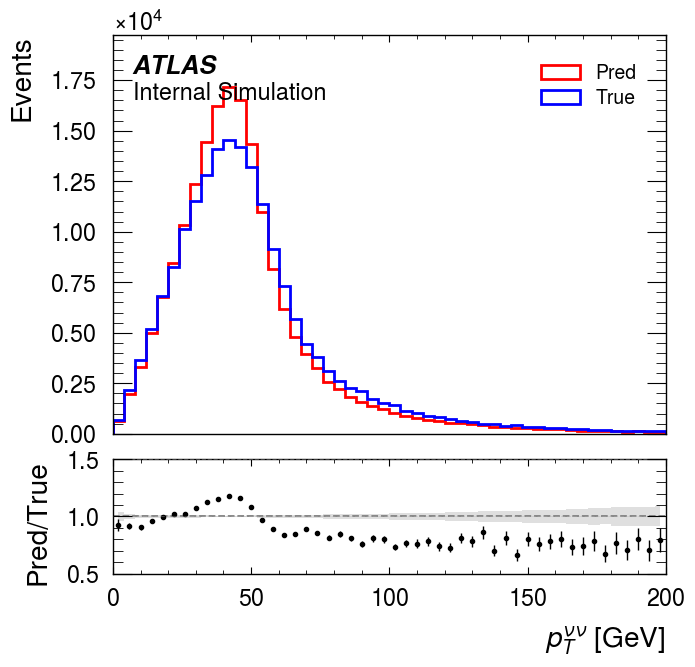

Rel err < 20%: 45.45 %


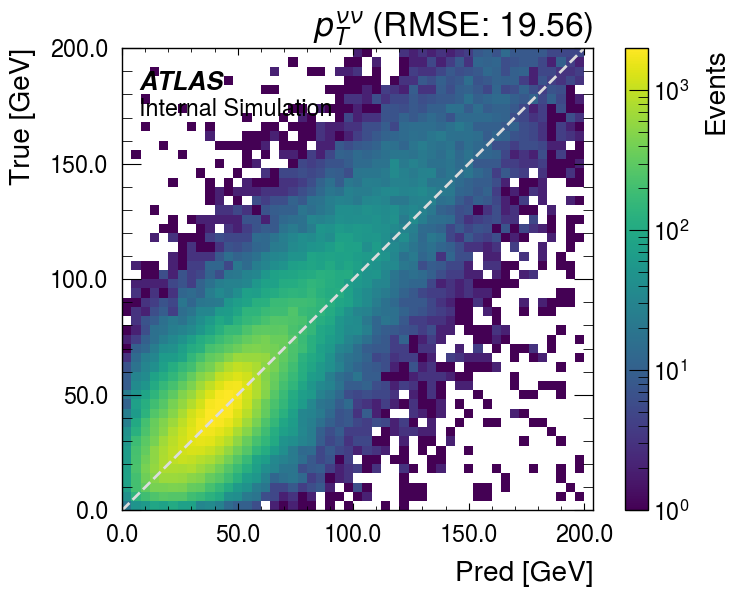

In [9]:
plot_1d_hist(pred_dinu_pt, true_dinu_pt, r"$p_T^{\nu\nu}$", bins_edges=np.linspace(0, 200, 51), unit="GeV")
plot_2d_hist(pred_dinu_pt, true_dinu_pt, r"$p_T^{\nu\nu}$", bins_edges=np.linspace(0, 200, 51), log=True, unit="GeV", vmax=2e3)

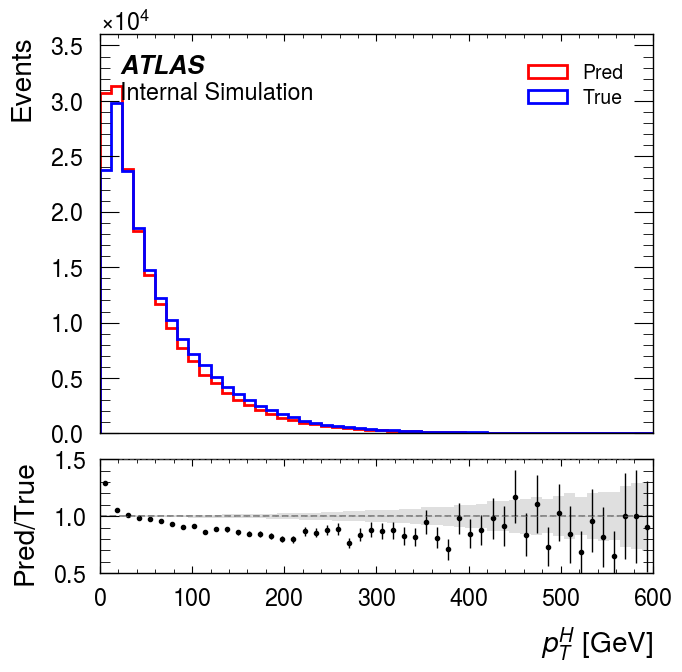

Rel err < 20%: 41.46 %


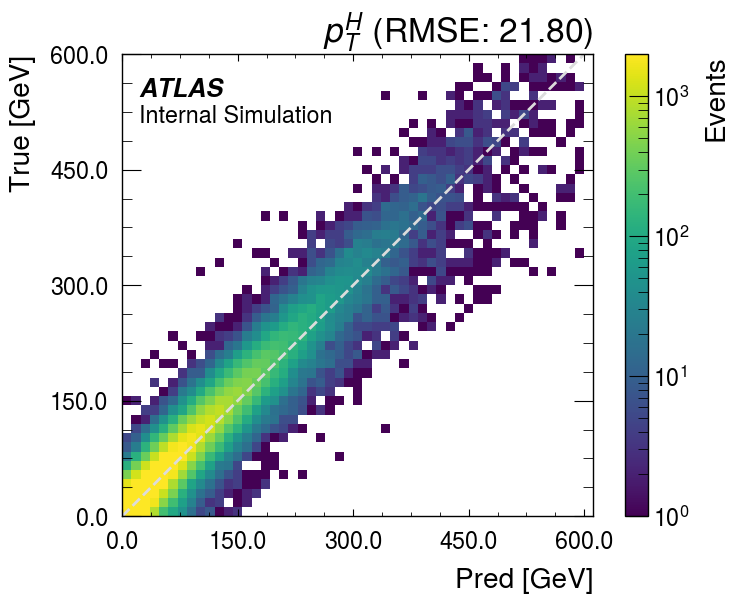

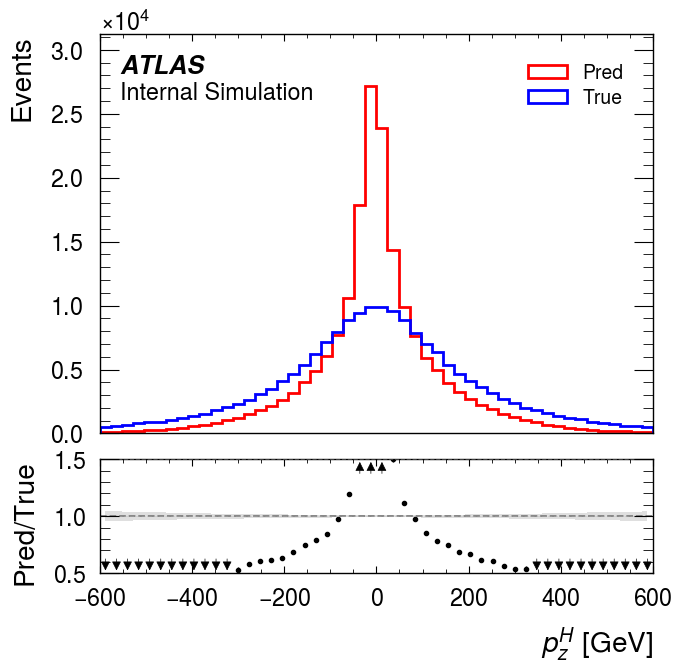

Rel err < 20%: 19.33 %


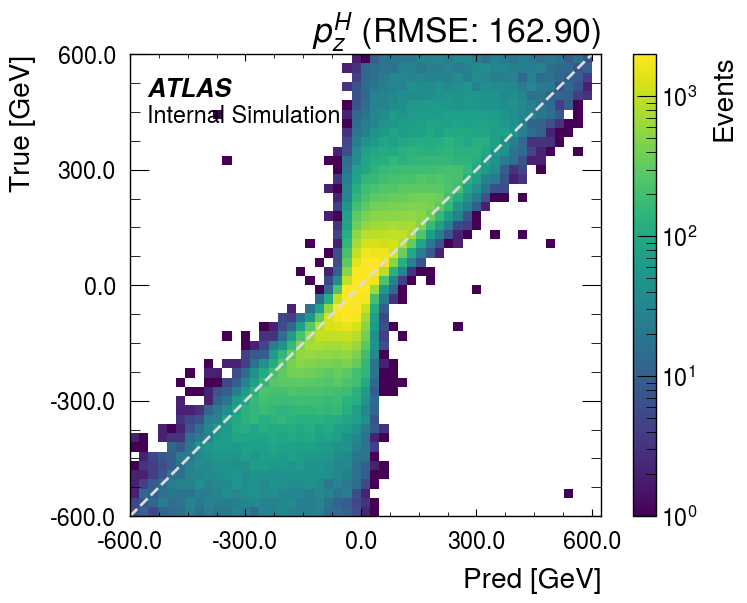

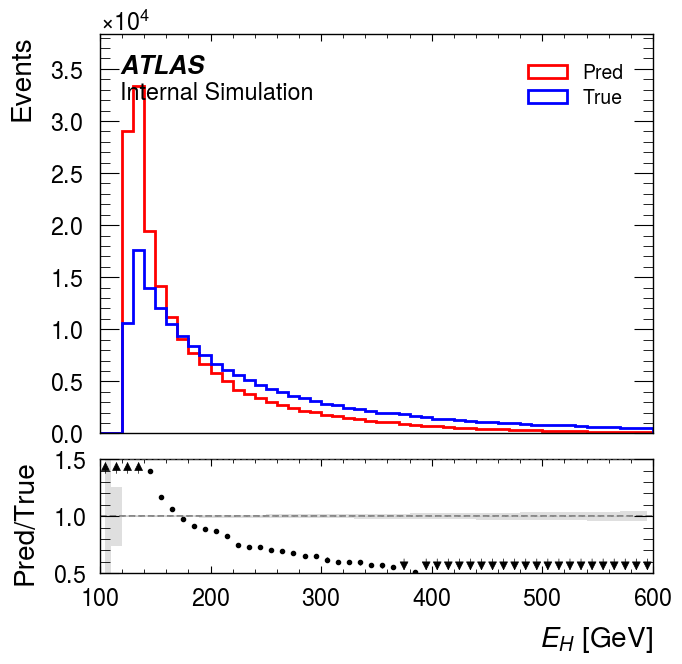

Rel err < 20%: 60.67 %


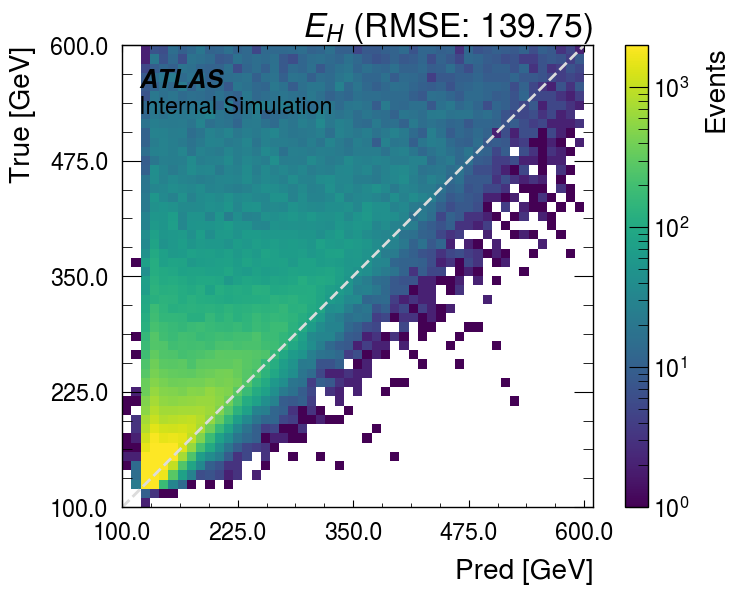

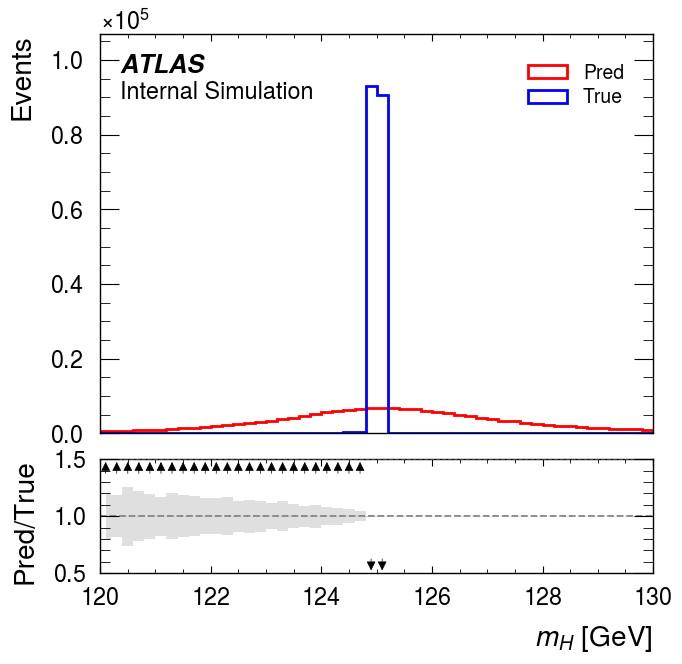

Mean predicted Higgs mass: 125.59 GeV, Std: 4.44 GeV
Rel err < 20%: 99.80 %


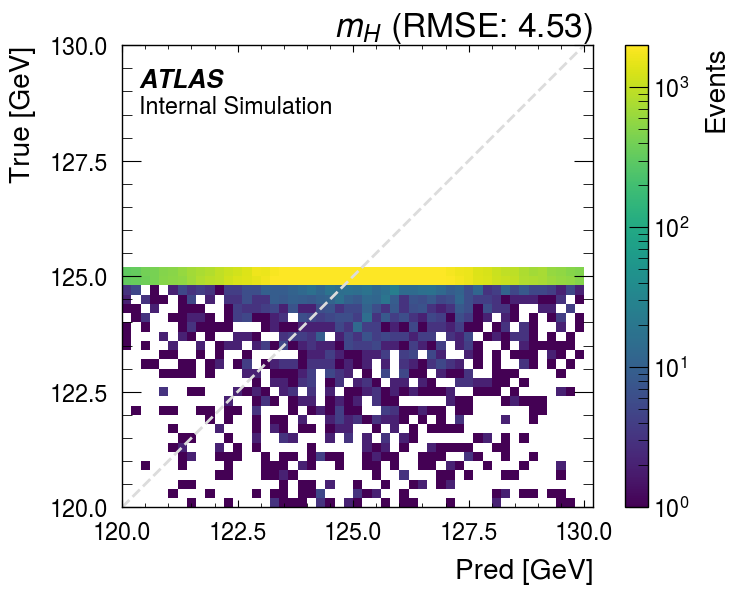

In [10]:
def safe_mass(mass2):
    return np.sqrt(np.abs(mass2))

pred_higgs_px = pred_w0_px + pred_w1_px
pred_higgs_py = pred_w0_py + pred_w1_py
pred_higgs_pz = pred_w0_pz + pred_w1_pz
pred_higgs_pt = np.sqrt(pred_higgs_px**2 + pred_higgs_py**2)
pred_higgs_energy = pred_w0_energy + pred_w1_energy
pred_higgs_mass_2 = pred_higgs_energy**2 - (pred_higgs_px**2 + pred_higgs_py**2 + pred_higgs_pz**2)
pred_higgs_mass = safe_mass(pred_higgs_mass_2)

true_higgs_px = true_w0_px + true_w1_px
true_higgs_py = true_w0_py + true_w1_py
true_higgs_pz = true_w0_pz + true_w1_pz
true_higgs_pt = np.sqrt(true_higgs_px**2 + true_higgs_py**2)
true_higgs_energy = true_w0_energy + true_w1_energy
true_higgs_mass_2 = true_higgs_energy**2 - (true_higgs_px**2 + true_higgs_py**2 + true_higgs_pz**2)
true_higgs_mass = safe_mass(true_higgs_mass_2)

# plot_1d_hist(pred_higgs_px, true_higgs_px, "$p_x^{H}$", bins_edges=np.linspace(-200, 200, 51), unit="GeV")
# plot_2d_hist(pred_higgs_px, true_higgs_px, "$p_x^{H}$", bins_edges=np.linspace(-200, 200, 51), log=True, unit="GeV", vmax=2e3)
# plot_1d_hist(pred_higgs_py, true_higgs_py, "$p_y^{H}$", bins_edges=np.linspace(-200, 200, 51), unit="GeV")
# plot_2d_hist(pred_higgs_py, true_higgs_py, "$p_y^{H}$", bins_edges=np.linspace(-200, 200, 51), log=True, unit="GeV", vmax=2e3)
plot_1d_hist(pred_higgs_pt, true_higgs_pt, "$p_T^{H}$", bins_edges=np.linspace(0, 600, 51), unit="GeV")
plot_2d_hist(pred_higgs_pt, true_higgs_pt, "$p_T^{H}$", bins_edges=np.linspace(0, 600, 51), log=True, unit="GeV", vmax=2e3)
plot_1d_hist(pred_higgs_pz, true_higgs_pz, "$p_z^{H}$", bins_edges=np.linspace(-600, 600, 51), unit="GeV")
plot_2d_hist(pred_higgs_pz, true_higgs_pz, "$p_z^{H}$", bins_edges=np.linspace(-600, 600, 51), log=True, unit="GeV", vmax=2e3)
plot_1d_hist(pred_higgs_energy, true_higgs_energy, "$E_H$", bins_edges=np.linspace(100, 600, 51), unit="GeV")
plot_2d_hist(pred_higgs_energy, true_higgs_energy, "$E_H$", bins_edges=np.linspace(100, 600, 51), log=True, unit="GeV", vmax=2e3)
plot_1d_hist(pred_higgs_mass, true_higgs_mass, "$m_H$", bins_edges=np.linspace(120, 130, 51), unit="GeV")
print(f"Mean predicted Higgs mass: {pred_higgs_mass.mean():.2f} GeV, Std: {pred_higgs_mass.std():.2f} GeV")
plot_2d_hist(pred_higgs_mass, true_higgs_mass, "$m_H$", bins_edges=np.linspace(120, 130, 51), log=True, unit="GeV", vmax=2e3)


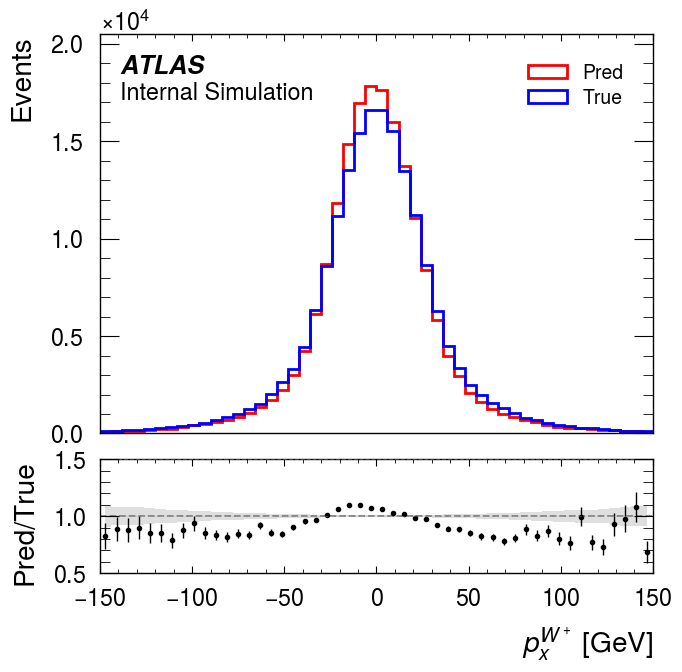

Rel err < 20%: 18.99 %


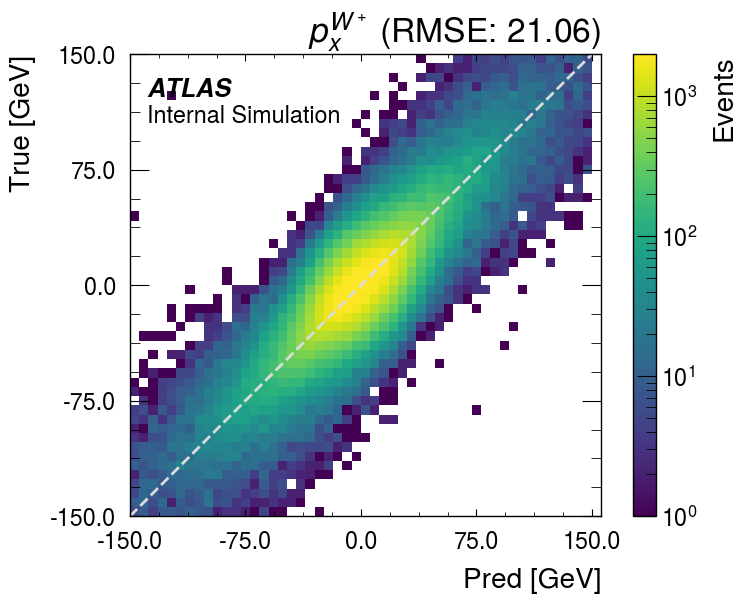

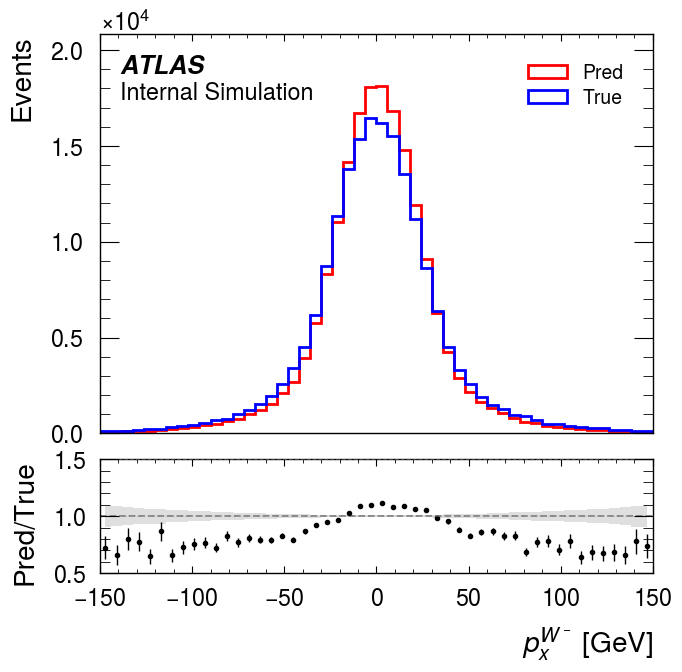

Rel err < 20%: 18.32 %


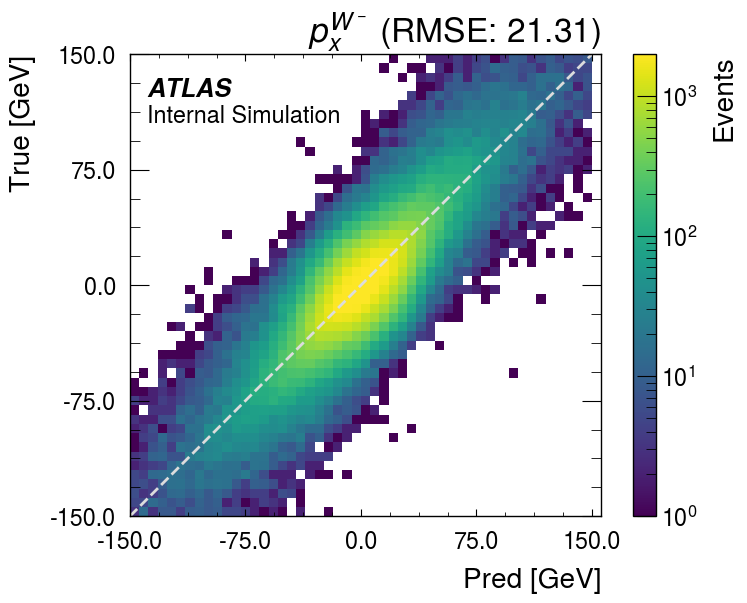

In [11]:
bins = np.linspace(-150, 150, 51)
plot_1d_hist(pred_w0_px, true_w0_px, bins_edges=bins, name=r"$p_x^{W^+}$")
plot_2d_hist(pred_w0_px, true_w0_px, name=r"$p_x^{W^+}$", bins_edges=bins, log=True, vmax=2e3)
plot_1d_hist(pred_w1_px, true_w1_px, bins_edges=bins, name=r"$p_x^{W^-}$")
plot_2d_hist(pred_w1_px, true_w1_px, name=r"$p_x^{W^-}$", bins_edges=bins, log=True, vmax=2e3)

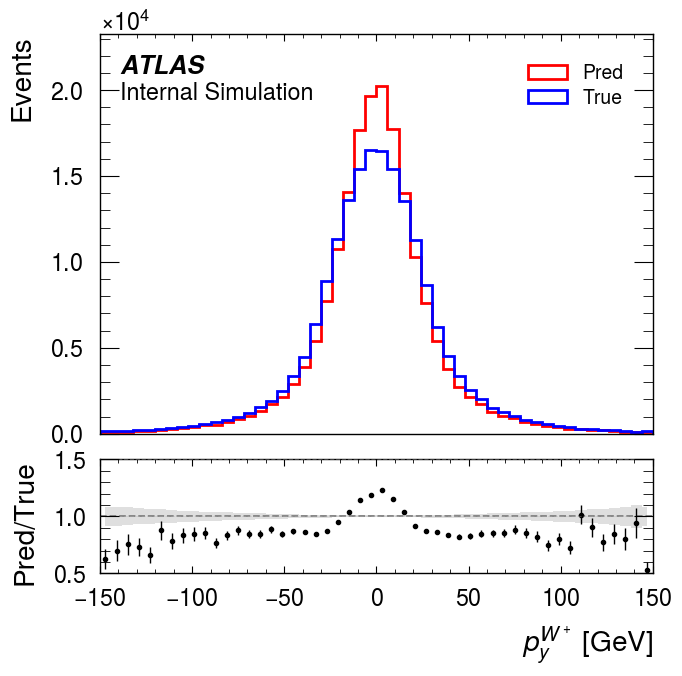

Rel err < 20%: 20.28 %


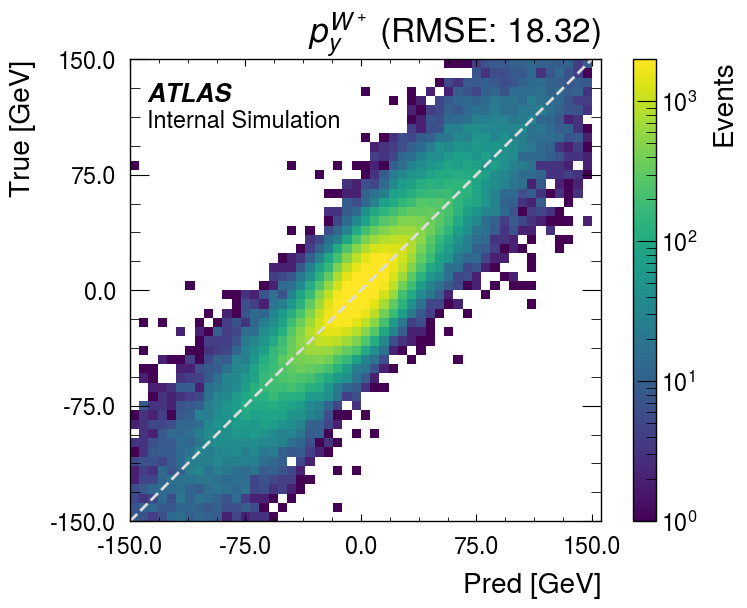

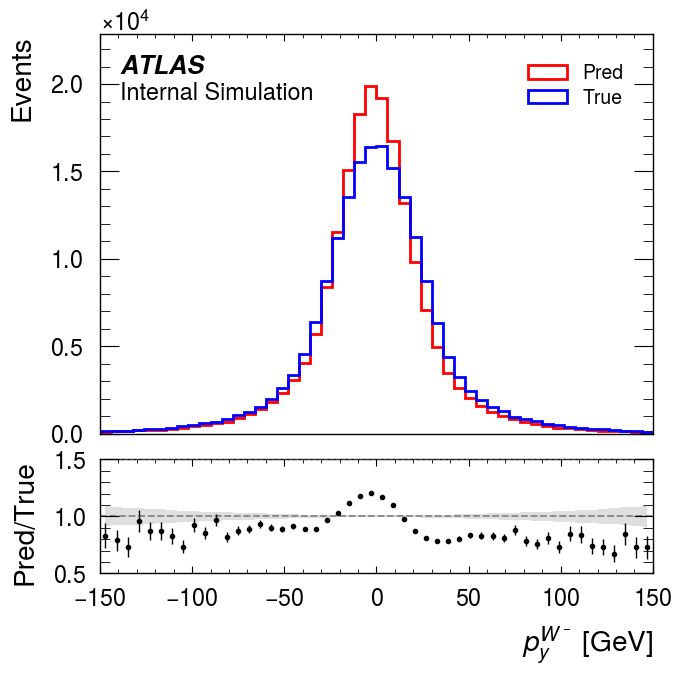

Rel err < 20%: 20.56 %


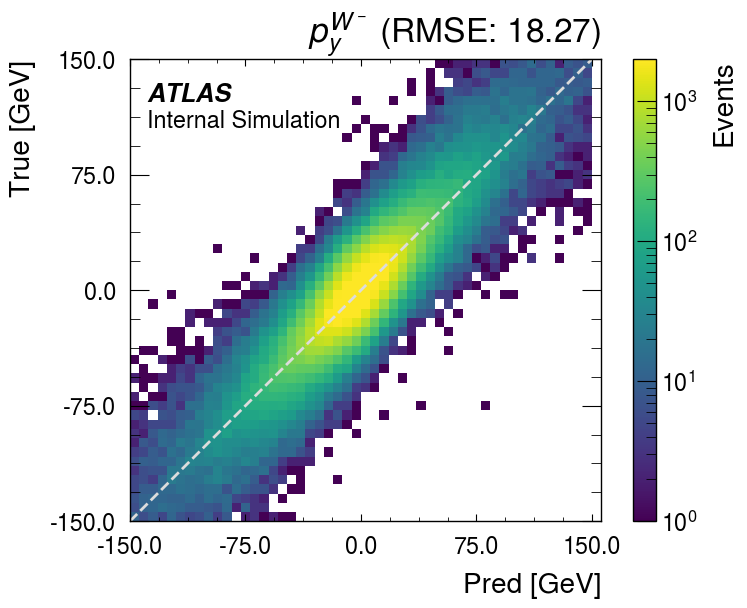

In [12]:
bins = np.linspace(-150, 150, 51)
plot_1d_hist(pred_w0_py, true_w0_py, bins_edges=bins, name=r"$p_y^{W^+}$")
plot_2d_hist(pred_w0_py, true_w0_py, name=r"$p_y^{W^+}$", bins_edges=bins, log=True, vmax=2e3)
plot_1d_hist(pred_w1_py, true_w1_py, bins_edges=bins, name=r"$p_y^{W^-}$")
plot_2d_hist(pred_w1_py, true_w1_py, name=r"$p_y^{W^-}$", bins_edges=bins, log=True, vmax=2e3)

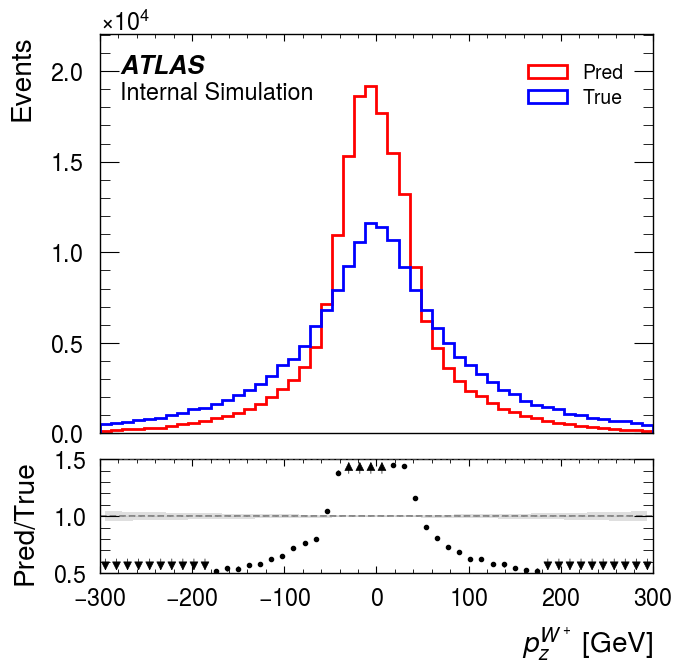

Rel err < 20%: 19.56 %


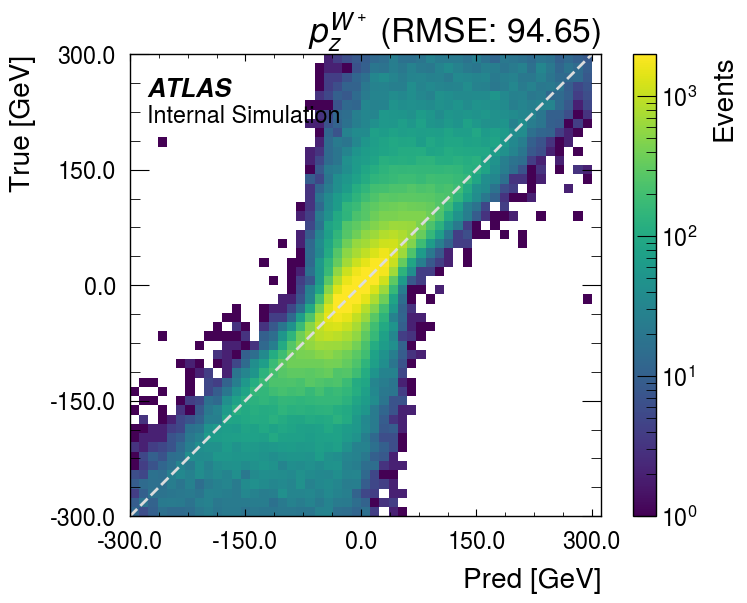

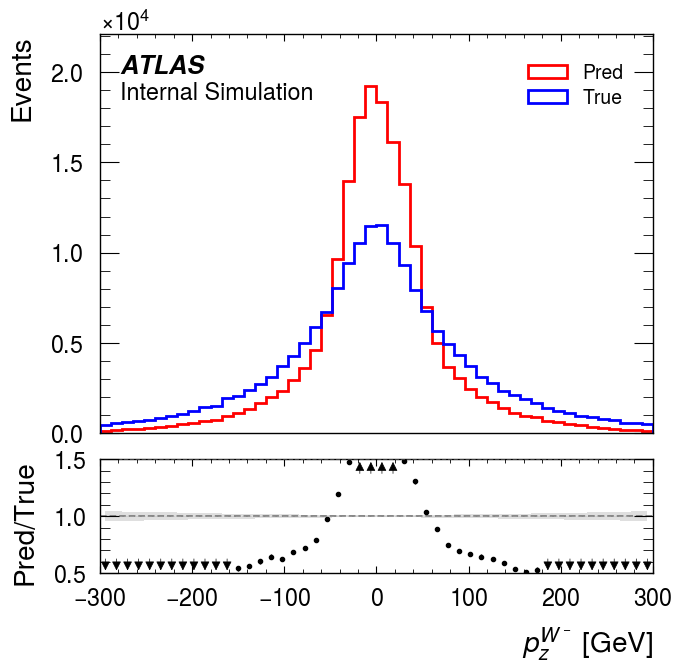

Rel err < 20%: 19.61 %


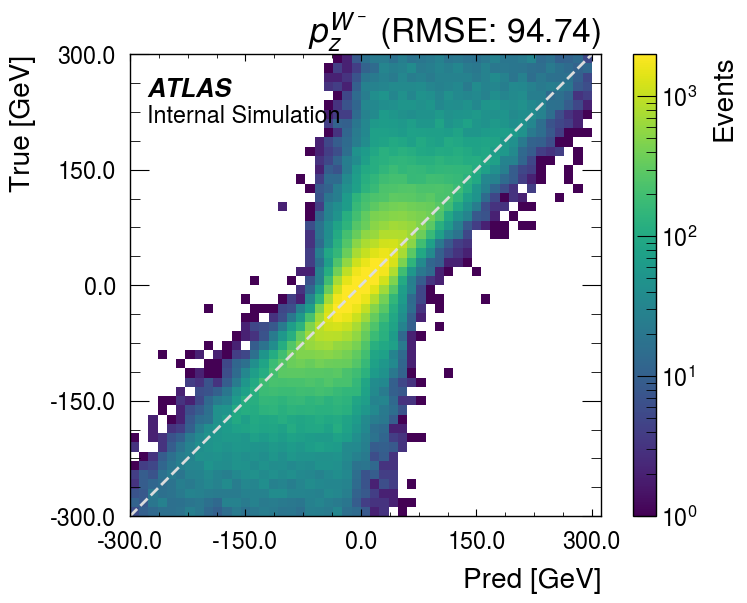

In [13]:
bins = np.linspace(-300, 300, 51)
plot_1d_hist(pred_w0_pz, true_w0_pz, bins_edges=bins, name=r"$p_z^{W^+}$")
plot_2d_hist(pred_w0_pz, true_w0_pz, name=r"$p_z^{W^+}$", bins_edges=bins, log=True, vmax=2e3)
plot_1d_hist(pred_w1_pz, true_w1_pz, bins_edges=bins, name=r"$p_z^{W^-}$")
plot_2d_hist(pred_w1_pz, true_w1_pz, name=r"$p_z^{W^-}$", bins_edges=bins, log=True, vmax=2e3)

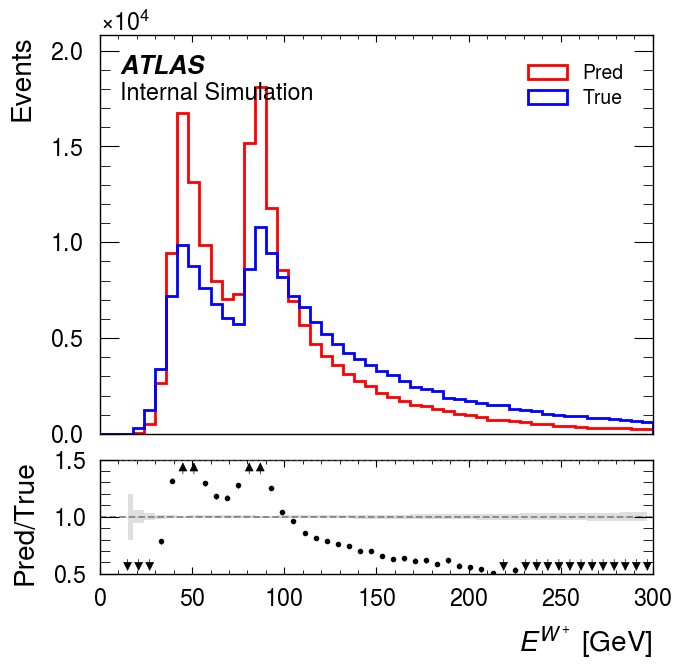

Rel err < 20%: 50.26 %


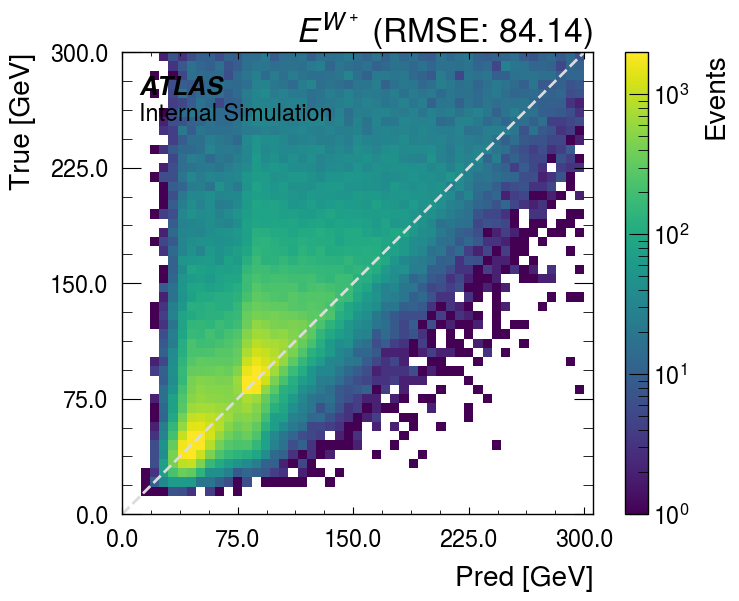

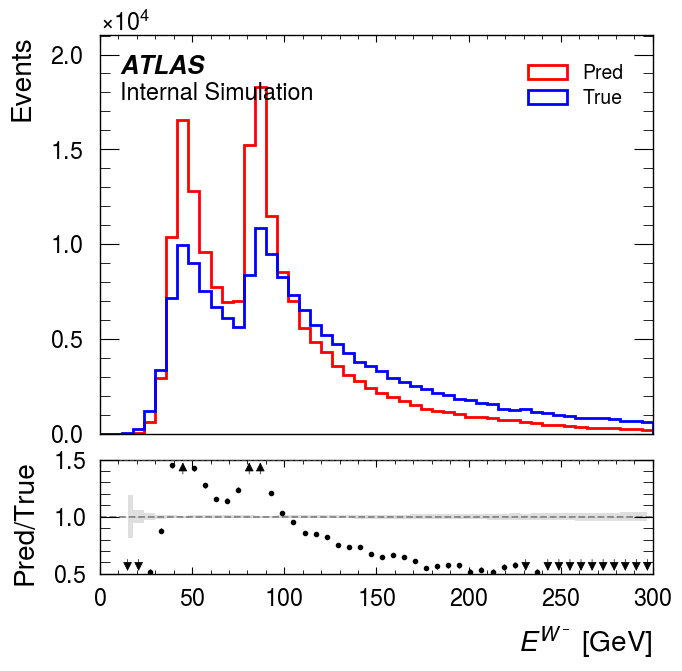

Rel err < 20%: 50.00 %


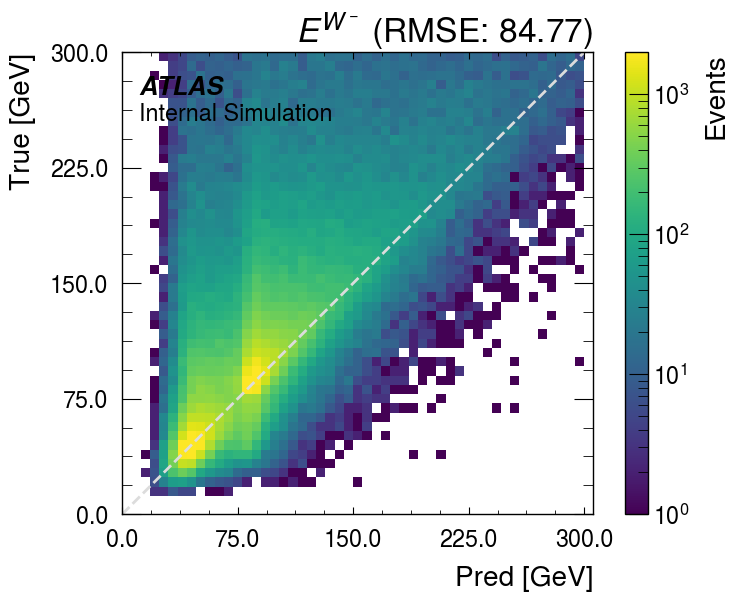

In [14]:
bins = np.linspace(0, 300, 51)
plot_1d_hist(pred_w0_energy, true_w0_energy, bins_edges=bins, name=r"$E^{W^+}$")
plot_2d_hist(pred_w0_energy, true_w0_energy, name=r"$E^{W^+}$", bins_edges=bins, log=True, color="black", vmax=2e3)
plot_1d_hist(pred_w1_energy, true_w1_energy, bins_edges=bins, name=r"$E^{W^-}$")
plot_2d_hist(pred_w1_energy, true_w1_energy, name=r"$E^{W^-}$", bins_edges=bins, log=True, color="black", vmax=2e3)

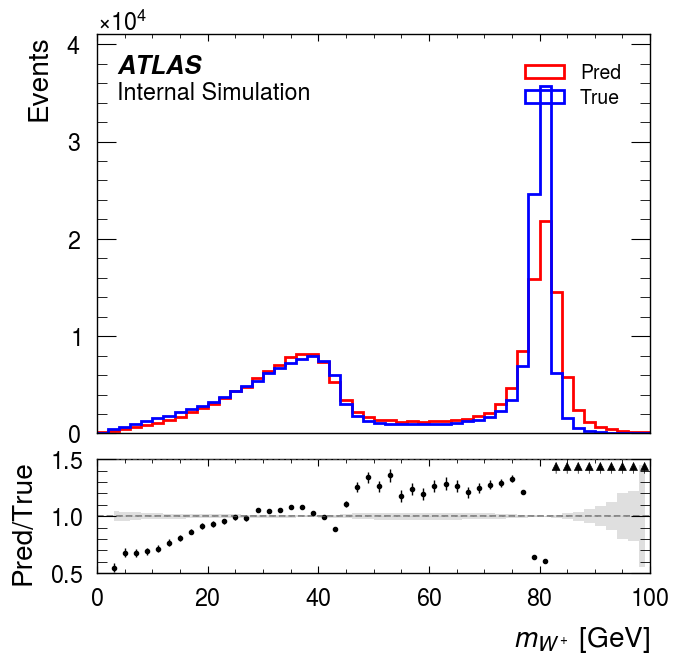

Rel err < 20%: 54.98 %


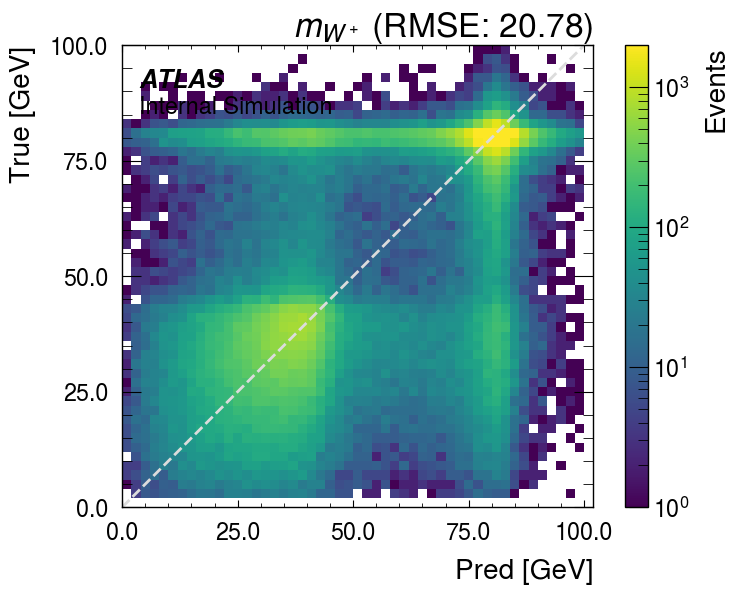

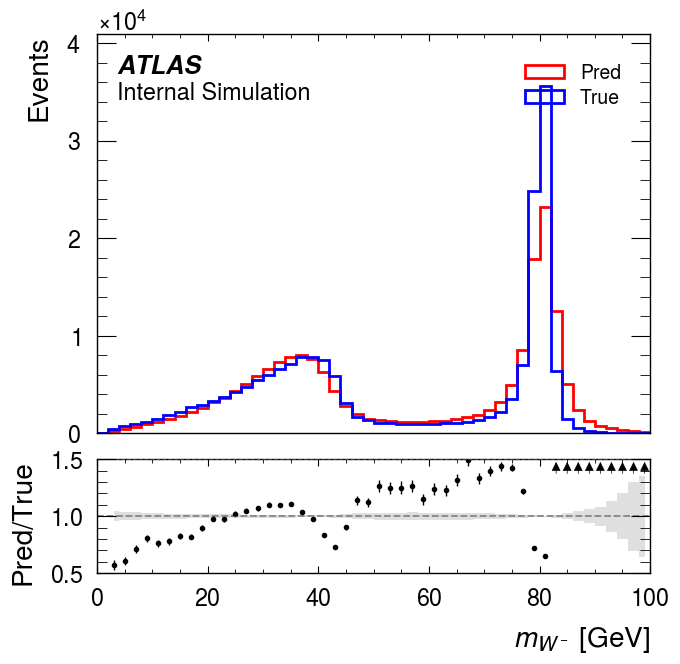

Rel err < 20%: 55.06 %


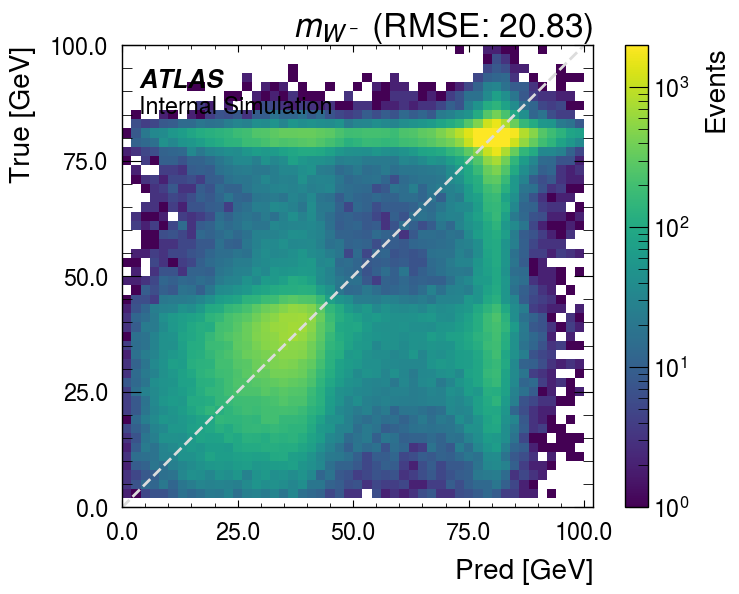

In [15]:
bins = np.linspace(0, 100, 51)
pred_w0_mass = safe_mass(pred_w0_mass_2)
pred_w1_mass = safe_mass(pred_w1_mass_2)
true_w0_mass = safe_mass(true_w0_mass_2)
true_w1_mass = safe_mass(true_w1_mass_2)

plot_1d_hist(pred_w0_mass, true_w0_mass, bins_edges=bins, name=r"$m_{W^+}$", unit="GeV")
plot_2d_hist(pred_w0_mass, true_w0_mass, name=r"$m_{W^+}$", bins_edges=bins, log=True, unit="GeV", vmax=2e3)
plot_1d_hist(pred_w1_mass, true_w1_mass, bins_edges=bins, name=r"$m_{W^-}$", unit="GeV")
plot_2d_hist(pred_w1_mass, true_w1_mass, name=r"$m_{W^-}$", bins_edges=bins, log=True, unit="GeV", vmax=2e3)


In [16]:
# bins = np.linspace(0, 100, 51)

# # W0: infer the neutrino from the predicted W and test the swapped lepton.
# diff_w0 = pred_w0_mass - true_w0_mass
# pred_nu0_px = pred_w0_px - true_lep0_px
# pred_nu0_py = pred_w0_py - true_lep0_py
# pred_nu0_pz = pred_w0_pz - true_lep0_pz
# pred_nu0_energy = pred_w0_energy - true_lep0_energy
# pred_nu0_mass_2 = (
#     pred_nu0_energy**2
#     - (pred_nu0_px**2 + pred_nu0_py**2 + pred_nu0_pz**2)
# )
# pred_nu0_mass = safe_mass(pred_nu0_mass_2)

# pred_w0_px_swap = pred_nu0_px + true_lep1_px
# pred_w0_py_swap = pred_nu0_py + true_lep1_py
# pred_w0_pz_swap = pred_nu0_pz + true_lep1_pz
# pred_w0_energy_swap = pred_nu0_energy + true_lep1_energy
# pred_w0_mass_swap = safe_mass(
#     pred_w0_energy_swap**2
#     - (pred_w0_px_swap**2 + pred_w0_py_swap**2 + pred_w0_pz_swap**2)
# )
# diff_w0_swap = pred_w0_mass_swap - true_w0_mass
# corr_mask_w0 = np.abs(diff_w0_swap) < np.abs(diff_w0)
# corr_pred_w0_px = np.where(corr_mask_w0, pred_w0_px_swap, pred_w0_px)
# corr_pred_w0_py = np.where(corr_mask_w0, pred_w0_py_swap, pred_w0_py)
# corr_pred_w0_pz = np.where(corr_mask_w0, pred_w0_pz_swap, pred_w0_pz)
# corr_pred_w0_energy = np.where(corr_mask_w0, pred_w0_energy_swap, pred_w0_energy)
# corr_pred_w0_p4 = np.stack([corr_pred_w0_px, corr_pred_w0_py, corr_pred_w0_pz, corr_pred_w0_energy], axis=1)
# corr_pred_w0_mass = np.where(corr_mask_w0, pred_w0_mass_swap, pred_w0_mass)

# # W1: mirror the same correction using the opposite lepton assignment.
# diff_w1 = pred_w1_mass - true_w1_mass
# pred_nu1_px = pred_w1_px - true_lep1_px
# pred_nu1_py = pred_w1_py - true_lep1_py
# pred_nu1_pz = pred_w1_pz - true_lep1_pz
# pred_nu1_energy = pred_w1_energy - true_lep1_energy
# pred_nu1_mass_2 = (
#     pred_nu1_energy**2
#     - (pred_nu1_px**2 + pred_nu1_py**2 + pred_nu1_pz**2)
# )
# pred_nu1_mass = safe_mass(pred_nu1_mass_2)

# pred_w1_px_swap = pred_nu1_px + true_lep0_px
# pred_w1_py_swap = pred_nu1_py + true_lep0_py
# pred_w1_pz_swap = pred_nu1_pz + true_lep0_pz
# pred_w1_energy_swap = pred_nu1_energy + true_lep0_energy
# pred_w1_mass_swap = safe_mass(
#     pred_w1_energy_swap**2
#     - (pred_w1_px_swap**2 + pred_w1_py_swap**2 + pred_w1_pz_swap**2)
# )
# diff_w1_swap = pred_w1_mass_swap - true_w1_mass
# corr_mask_w1 = np.abs(diff_w1_swap) < np.abs(diff_w1)
# corr_pred_w1_px = np.where(corr_mask_w1, pred_w1_px_swap, pred_w1_px)
# corr_pred_w1_py = np.where(corr_mask_w1, pred_w1_py_swap, pred_w1_py)
# corr_pred_w1_pz = np.where(corr_mask_w1, pred_w1_pz_swap, pred_w1_pz)
# corr_pred_w1_energy = np.where(corr_mask_w1, pred_w1_energy_swap, pred_w1_energy)
# corr_pred_w1_p4 = np.stack([corr_pred_w1_px, corr_pred_w1_py, corr_pred_w1_pz, corr_pred_w1_energy], axis=1)
# corr_pred_w1_mass = np.where(corr_mask_w1, pred_w1_mass_swap, pred_w1_mass)

# # True neutrino masses for reference plots.
# true_nu0_px = true_w0_px - true_lep0_px
# true_nu0_py = true_w0_py - true_lep0_py
# true_nu0_pz = true_w0_pz - true_lep0_pz
# true_nu0_energy = true_w0_energy - true_lep0_energy
# true_nu0_mass = safe_mass(
#     true_nu0_energy**2
#     - (true_nu0_px**2 + true_nu0_py**2 + true_nu0_pz**2)
# )

# true_nu1_px = true_w1_px - true_lep1_px
# true_nu1_py = true_w1_py - true_lep1_py
# true_nu1_pz = true_w1_pz - true_lep1_pz
# true_nu1_energy = true_w1_energy - true_lep1_energy
# true_nu1_mass = safe_mass(
#     true_nu1_energy**2
#     - (true_nu1_px**2 + true_nu1_py**2 + true_nu1_pz**2)
# )

# plot_1d_hist(corr_pred_w0_mass, true_w0_mass, bins_edges=bins, name=r"Corrected $m_{W^+}$", unit="GeV")
# plot_2d_hist(corr_pred_w0_mass, true_w0_mass, name=r"Corrected $m_{W^+}$", bins_edges=bins, log=True, unit="GeV", vmax=2e3)
# plot_1d_hist(corr_pred_w1_mass, true_w1_mass, bins_edges=bins, name=r"Corrected $m_{W^-}$", unit="GeV")
# plot_2d_hist(corr_pred_w1_mass, true_w1_mass, name=r"Corrected $m_{W^-}$", bins_edges=bins, log=True, unit="GeV", vmax=2e3)


In [17]:
# diff_mass_pos = pred_w0_mass - true_w0_mass
# diff_mass_neg = pred_w1_mass - true_w1_mass
# bins_edges = np.linspace(-100, 100, 51)
# plt.hist(diff_mass_pos, bins=bins_edges, histtype='step', color='red',label=r"$\Delta m_{W^+}$")
# plt.hist(diff_mass_neg, bins=bins_edges, histtype='step', color='blue',label=r"$\Delta m_{W^-}$")
# plt.xlabel(r"$\Delta m_W$ [GeV]")
# plt.ylabel("Events")
# plt.legend()
# plt.show()

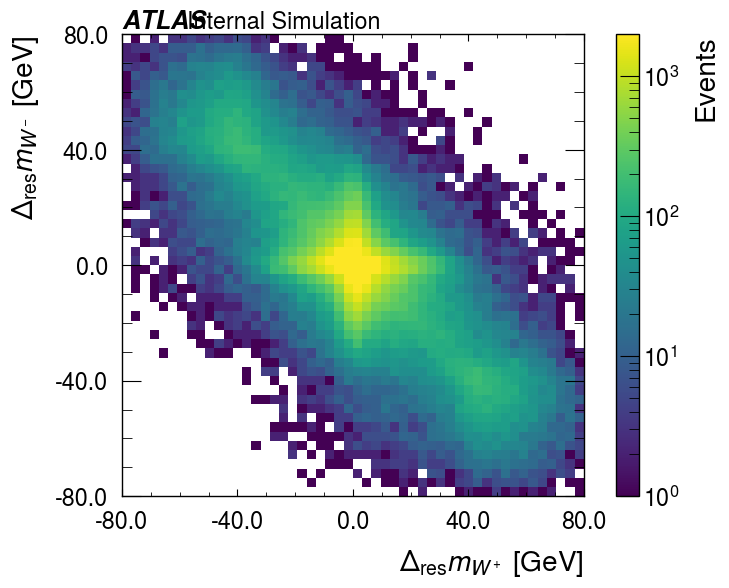

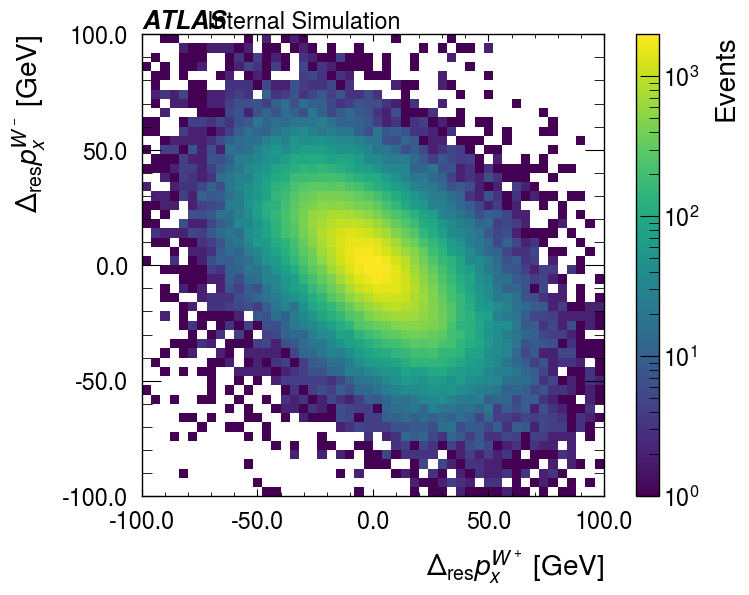

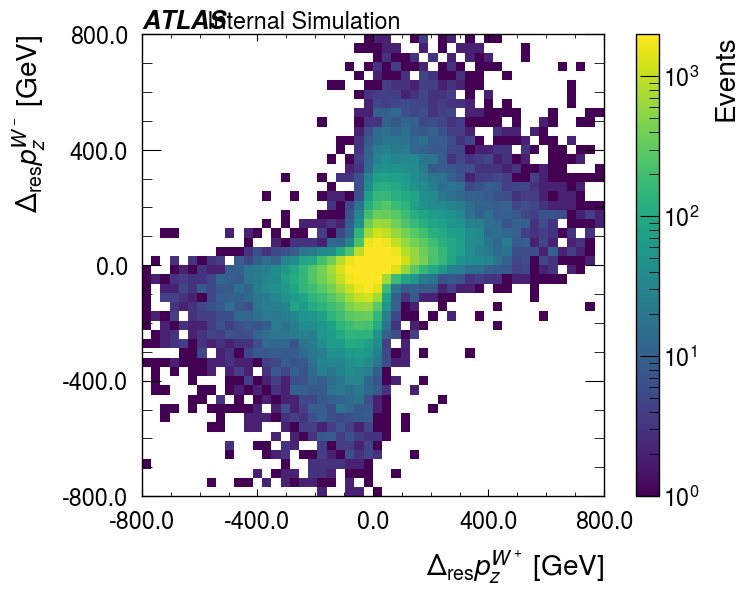

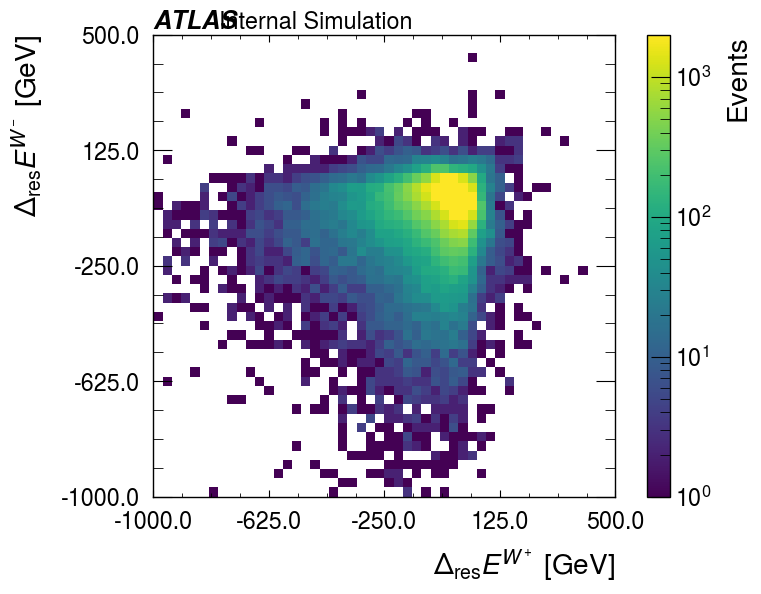

In [18]:
w0_mass_res = pred_w0_mass - true_w0_mass
w1_res = pred_w1_mass - true_w1_mass
plot_2d_res_hist(w0_mass_res, w1_res, name_pos=r"$m_{W^+}$", name_neg=r"$m_{W^-}$", bins_edges=np.linspace(-80, 80, 51), log=True, unit="GeV", color="black", vmax=2e3)

w0_px_res = pred_w0_px - true_w0_px
w1_px_res = pred_w1_px - true_w1_px
plot_2d_res_hist(w0_px_res, w1_px_res, name_pos=r"$p_x^{W^+}$", name_neg=r"$p_x^{W^-}$", bins_edges=np.linspace(-100, 100, 51), log=True, unit="GeV", color="black", vmax=2e3)

w0_pz_res = pred_w0_pz - true_w0_pz
w1_pz_res = pred_w1_pz - true_w1_pz
plot_2d_res_hist(w0_pz_res, w1_pz_res, name_pos=r"$p_z^{W^+}$", name_neg=r"$p_z^{W^-}$", bins_edges=np.linspace(-800, 800, 51), log=True, unit="GeV", color="black", vmax=2e3)

w0_energy_res = pred_w0_energy - true_w0_energy
w1_energy_res = pred_w1_energy - true_w1_energy
plot_2d_res_hist(w0_energy_res, w1_energy_res, name_pos=r"$E^{W^+}$", name_neg=r"$E^{W^-}$", bins_edges=np.linspace(-1000, 500, 51), log=True, unit="GeV", color="black", vmax=2e3)

In [19]:
def alpha_func(lep_on_p4, neu_on_p4, lep_off_p4, neu_off_p4):
    
    def _cal_mass(p4):
        return np.sqrt(p4[:, 3]**2 - p4[:, 0]**2 - p4[:, 1]**2 - p4[:, 2]**2)
    
    def _cal_norm(p4):
        return np.sqrt(p4[:, 0]**2 + p4[:, 1]**2 + p4[:, 2]**2)
    
    # dinu_p4 = neu_on_p4 + neu_off_p4
    # dinu_mass = _cal_mass(dinu_p4)
    dinu_lep_on_p4 = lep_on_p4 + neu_on_p4 + neu_off_p4
    dinu_lep_on_mass = _cal_mass(dinu_lep_on_p4)
    dinu_lep_off_p4 = lep_off_p4 + neu_on_p4 + neu_off_p4
    dinu_lep_off_mass = _cal_mass(dinu_lep_off_p4)
        
    alpha = np.where(
        dinu_lep_on_mass > dinu_lep_off_mass,
        _cal_norm(neu_on_p4) / (_cal_norm(neu_on_p4) + _cal_norm(neu_off_p4) + 1e-16),
        _cal_norm(neu_off_p4) / (_cal_norm(neu_on_p4) + _cal_norm(neu_off_p4) + 1e-16)
    )
    
    return alpha

# true
true_w0_p4 = np.stack([true_w0_px, true_w0_py, true_w0_pz, true_w0_energy], axis=-1)
true_w1_p4 = np.stack([true_w1_px, true_w1_py, true_w1_pz, true_w1_energy], axis=-1)
true_lep0_p4 = np.stack([true_lep0_px, true_lep0_py, true_lep0_pz, true_lep0_energy], axis=-1)
true_lep1_p4 = np.stack([true_lep1_px, true_lep1_py, true_lep1_pz, true_lep1_energy], axis=-1)

# pred
pred_w0_p4 = np.stack([pred_w0_px, pred_w0_py, pred_w0_pz, pred_w0_energy], axis=-1)
pred_w1_p4 = np.stack([pred_w1_px, pred_w1_py, pred_w1_pz, pred_w1_energy], axis=-1)

w_mass_con = 80.379 # GeV
w_mass_con_2 = w_mass_con ** 2

true_0_on_mask = np.abs(true_w0_mass_2 - w_mass_con_2) < np.abs(true_w1_mass_2 - w_mass_con_2)
true_lep_on_p4 = np.where(true_0_on_mask[:, np.newaxis], true_lep0_p4, true_lep1_p4)
true_lep_off_p4 = np.where(true_0_on_mask[:, np.newaxis], true_lep1_p4, true_lep0_p4)
true_w_on_p4 = np.where(true_0_on_mask[:, np.newaxis], true_w0_p4, true_w1_p4)
true_w_off_p4 = np.where(true_0_on_mask[:, np.newaxis], true_w1_p4, true_w0_p4)
true_neu_on_p4 = true_w_on_p4 - true_lep_on_p4
true_neu_off_p4 = true_w_off_p4 - true_lep_off_p4

pred_0_on_mask = np.abs(pred_w0_mass_2 - w_mass_con_2) < np.abs(pred_w1_mass_2 - w_mass_con_2)
pred_w_on_p4 = np.where(pred_0_on_mask[:, np.newaxis], pred_w0_p4, pred_w1_p4)
pred_w_off_p4 = np.where(pred_0_on_mask[:, np.newaxis], pred_w1_p4, pred_w0_p4)
pred_neu_on_p4 = pred_w_on_p4 - true_lep_on_p4
pred_neu_off_p4 = pred_w_off_p4 - true_lep_off_p4

true_alpha = alpha_func(true_lep_on_p4, true_neu_on_p4, true_lep_off_p4, true_neu_off_p4)
pred_alpha = alpha_func(true_lep_on_p4, pred_neu_on_p4, true_lep_off_p4, pred_neu_off_p4)

/tmp/ipykernel_200951/4229498418.py:4: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(p4[:, 3]**2 - p4[:, 0]**2 - p4[:, 1]**2 - p4[:, 2]**2)


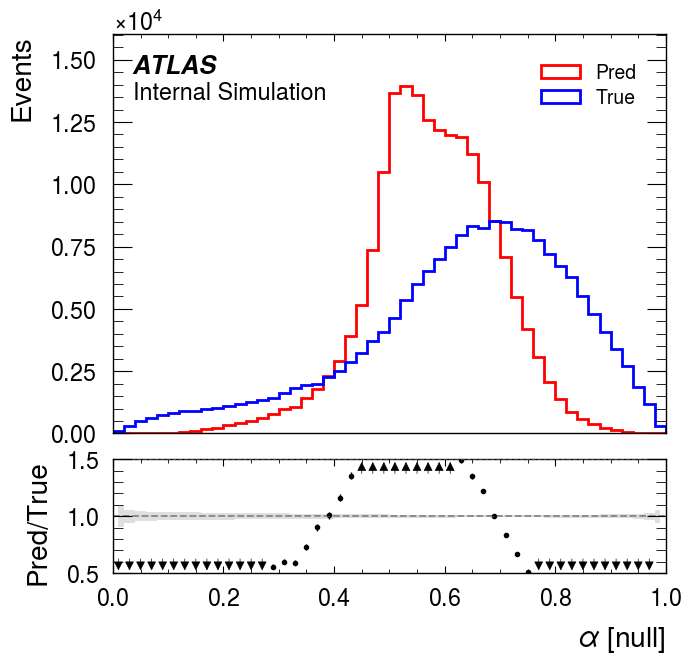

Rel err < 20%: 45.54 %


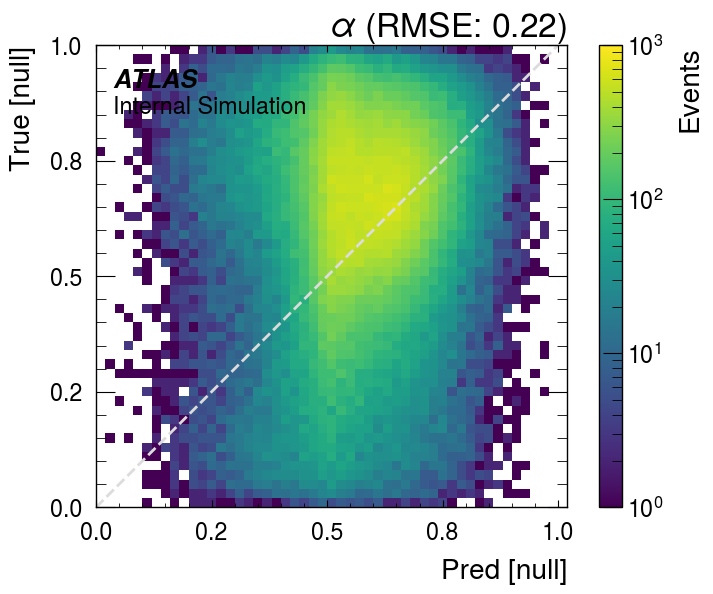

In [20]:
plot_1d_hist(pred_alpha, true_alpha, r"$\alpha$", np.linspace(0, 1, 51), unit="null")
plot_2d_hist(pred_alpha, true_alpha, r"$\alpha$", np.linspace(0, 1, 51), log=True, unit="null", color="black", vmax=1e3)

In [21]:
lep_p4 = np.concatenate([true_lep0_p4, true_lep1_p4], axis=1)
true_w_p4 = np.concatenate([true_w0_p4, true_w1_p4], axis=1)
pred_w_p4 = np.concatenate([pred_w0_p4, pred_w1_p4], axis=1)

def angular_features_like_training(lep_p4, true_w_p4, pred_w_p4, device):
    lep = torch.as_tensor(lep_p4, dtype=torch.float32, device=device)
    true_w = torch.as_tensor(true_w_p4, dtype=torch.float32, device=device)
    pred_w = torch.as_tensor(pred_w_p4, dtype=torch.float32, device=device)

    true_booster = TorchBooster(lep, true_w)
    pred_booster = TorchBooster(lep, pred_w)
    valid = true_booster.valid_rest_frame_mask() & pred_booster.valid_rest_frame_mask()

    true_ang = torch.stack(true_booster.lep_theta_phi_in_w_rest(), dim=-1)[valid]
    pred_ang = torch.stack(pred_booster.lep_theta_phi_in_w_rest(), dim=-1)[valid]
    return true_ang.cpu().numpy(), pred_ang.cpu().numpy(), valid.cpu().numpy()

true_ang, pred_ang, angular_valid = angular_features_like_training(lep_p4, true_w_p4, pred_w_p4, device)
print(f"Angular valid events: {angular_valid.sum()} / {len(angular_valid)}")

true_l0_theta_phi = (true_ang[:, 0], np.sin(true_ang[:, 1]), np.cos(true_ang[:, 1]))
true_l1_theta_phi = (true_ang[:, 2], np.sin(true_ang[:, 3]), np.cos(true_ang[:, 3]))
pred_l0_theta_phi = (pred_ang[:, 0], np.sin(pred_ang[:, 1]), np.cos(pred_ang[:, 1]))
pred_l1_theta_phi = (pred_ang[:, 2], np.sin(pred_ang[:, 3]), np.cos(pred_ang[:, 3]))


Angular valid events: 185968 / 185968


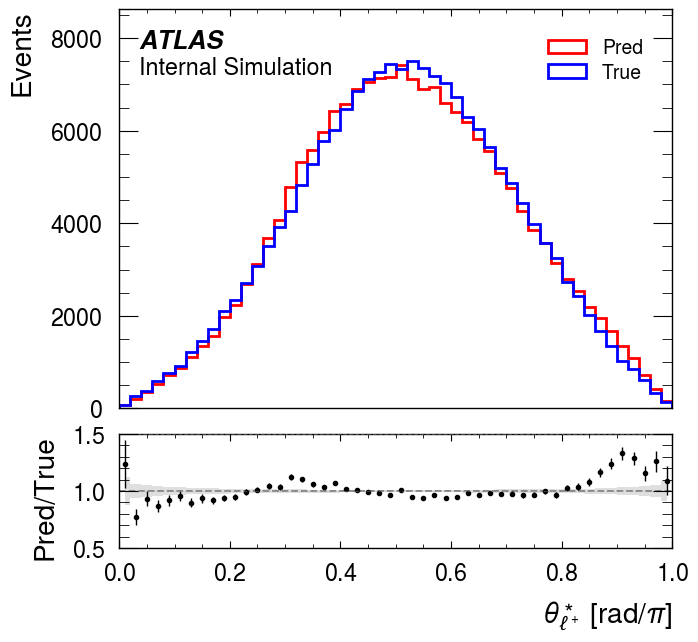

Rel err < 20%: 42.82 %


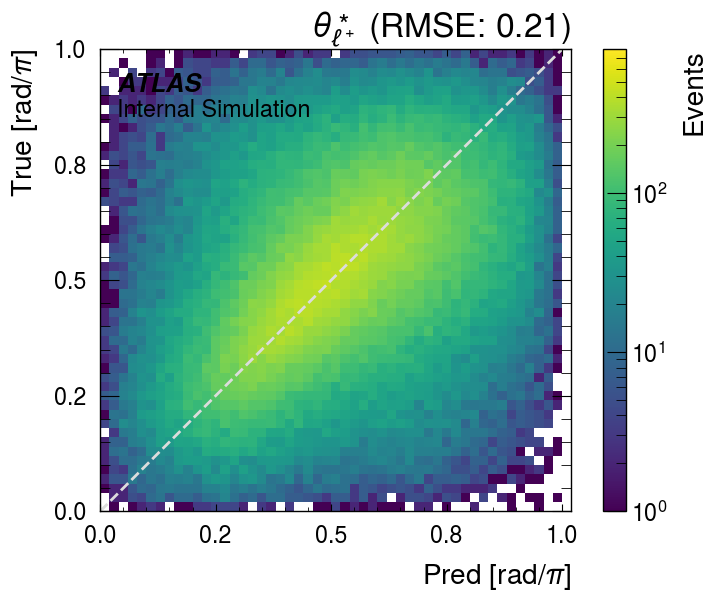

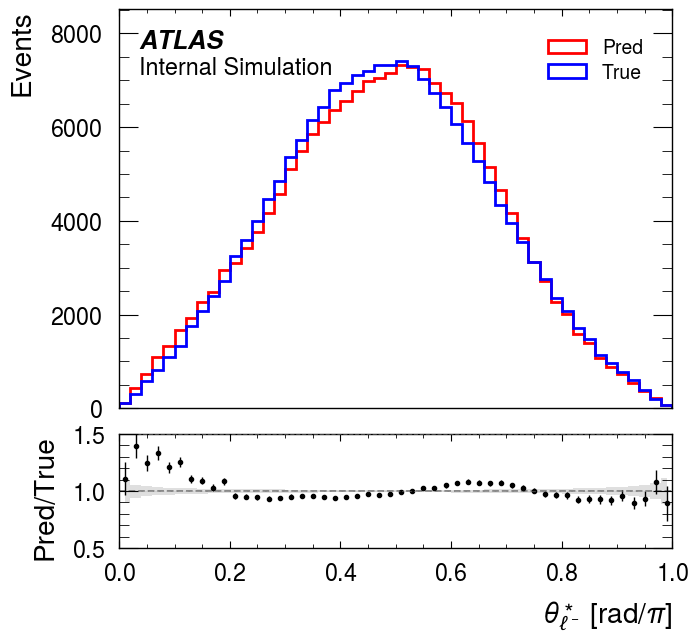

Rel err < 20%: 40.65 %


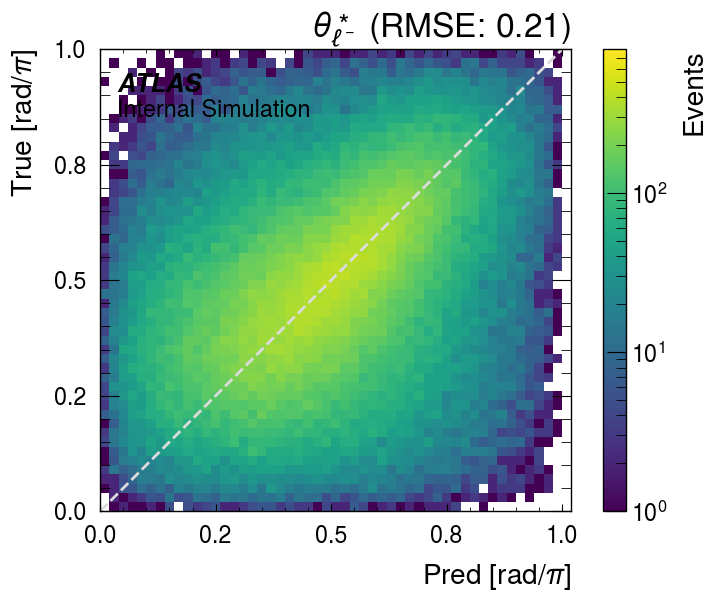

In [22]:
plot_1d_hist(pred_l0_theta_phi[0] / np.pi, true_l0_theta_phi[0] / np.pi, r"$\theta^\ast_{\ell^+}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
plot_2d_hist(pred_l0_theta_phi[0] / np.pi, true_l0_theta_phi[0] / np.pi, r"$\theta^\ast_{\ell^+}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=8e2)
plot_1d_hist(pred_l1_theta_phi[0] / np.pi, true_l1_theta_phi[0] / np.pi, r"$\theta^\ast_{\ell^-}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
plot_2d_hist(pred_l1_theta_phi[0] / np.pi, true_l1_theta_phi[0] / np.pi, r"$\theta^\ast_{\ell^-}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=8e2)

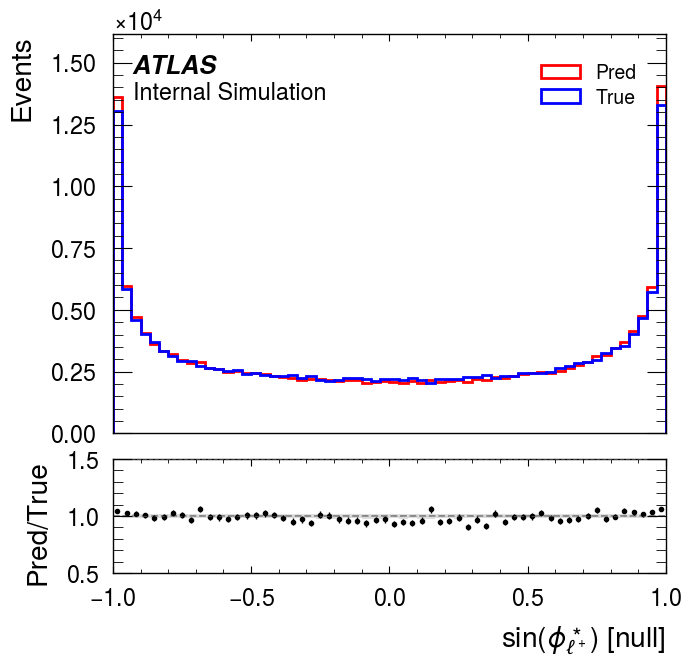

Rel err < 20%: 18.50 %


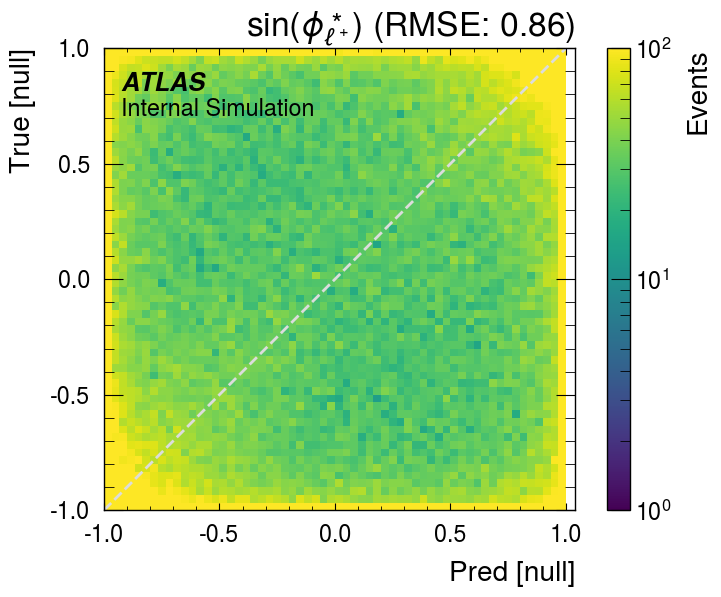

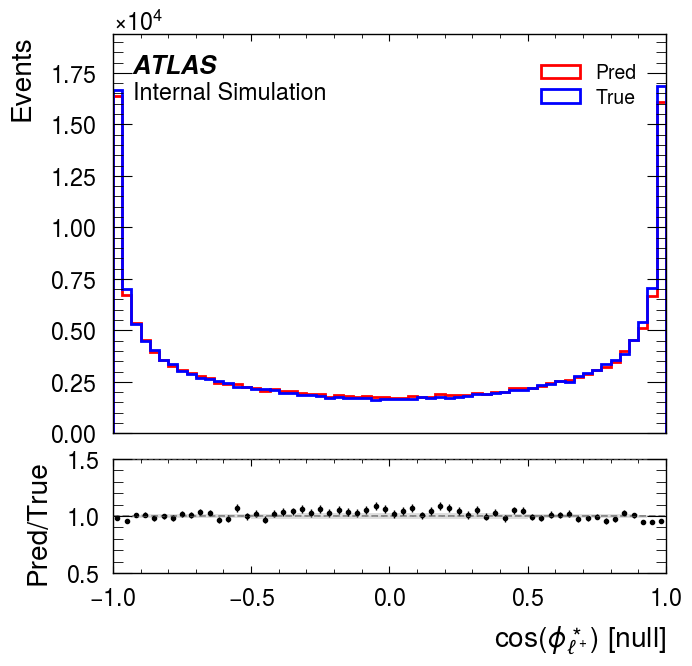

Rel err < 20%: 22.96 %


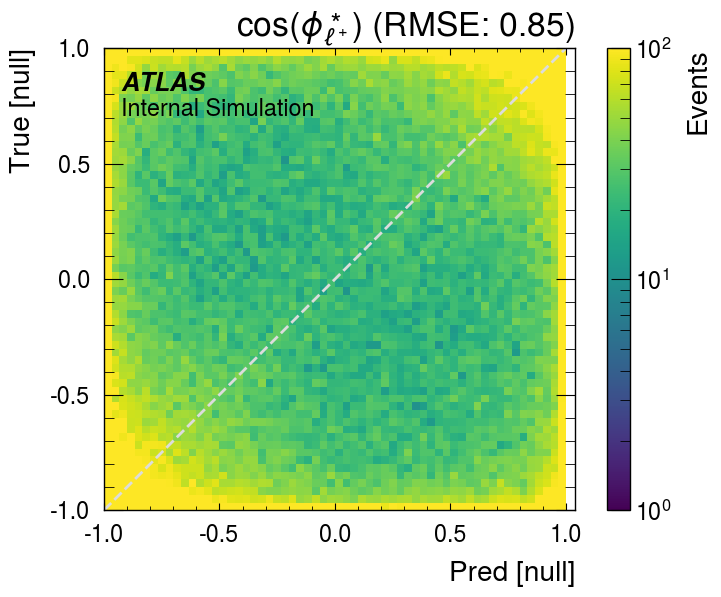

In [23]:
plot_1d_hist(pred_l0_theta_phi[1], true_l0_theta_phi[1], r"$\sin(\phi^\ast_{\ell^+})$", np.linspace(-1, 1, 61), unit="null")
plot_2d_hist(pred_l0_theta_phi[1], true_l0_theta_phi[1], r"$\sin(\phi^\ast_{\ell^+})$", np.linspace(-1, 1, 61), log=True, unit="null", color="black", vmax=1e2)
plot_1d_hist(pred_l0_theta_phi[2], true_l0_theta_phi[2], r"$\cos(\phi^\ast_{\ell^+})$", np.linspace(-1, 1, 61), unit="null")
plot_2d_hist(pred_l0_theta_phi[2], true_l0_theta_phi[2], r"$\cos(\phi^\ast_{\ell^+})$", np.linspace(-1, 1, 61), log=True, unit="null", color="black", vmax=1e2)

In [24]:
# plot_1d_hist(pred_l1_theta_phi[1], true_l1_theta_phi[1], r"$\sin(\phi^\ast_{\ell^-})$", np.linspace(-1, 1, 61), unit="null")
# plot_2d_hist(pred_l1_theta_phi[1], true_l1_theta_phi[1], r"$\sin(\phi^\ast_{\ell^-})$", np.linspace(-1, 1, 61), log=True, unit="null", color="black", vmax=1e2)
# plot_1d_hist(pred_l1_theta_phi[2], true_l1_theta_phi[2], r"$\cos(\phi^\ast_{\ell^-})$", np.linspace(-1, 1, 61), unit="null")
# plot_2d_hist(pred_l1_theta_phi[2], true_l1_theta_phi[2], r"$\cos(\phi^\ast_{\ell^-})$", np.linspace(-1, 1, 61), log=True, unit="null", color="black", vmax=1e2)

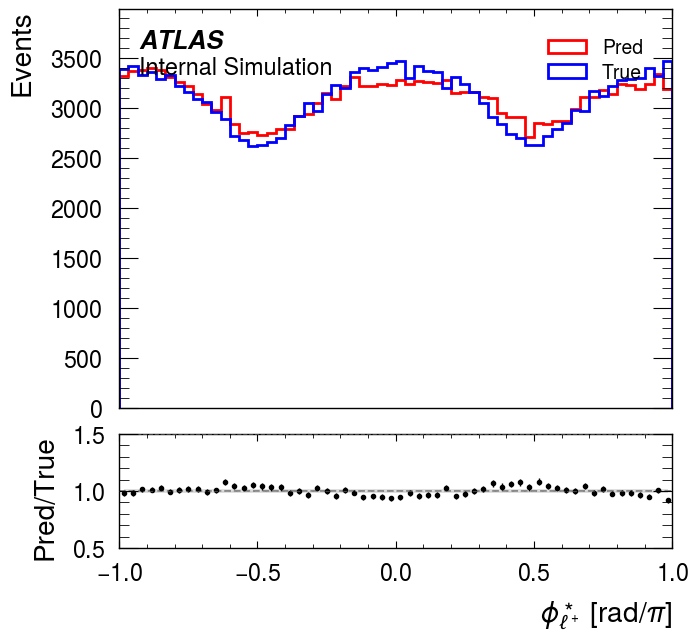

Rel err < 20%: 16.42 %


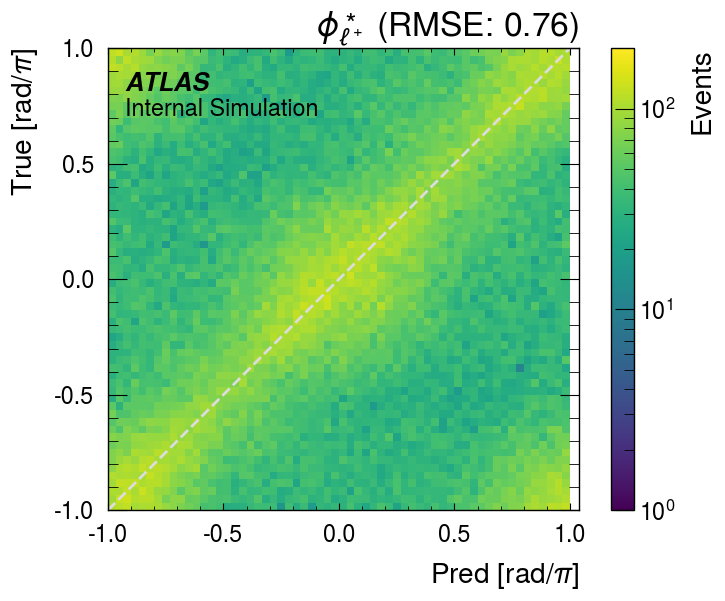

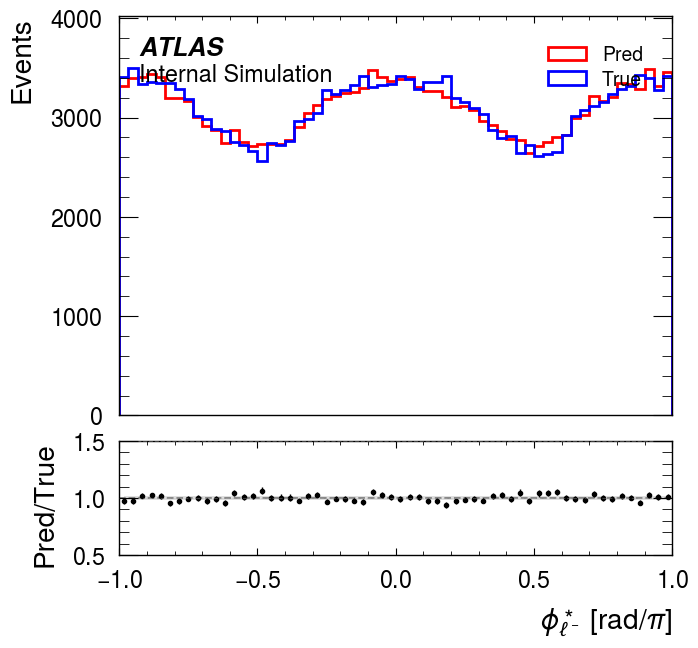

Rel err < 20%: 16.28 %


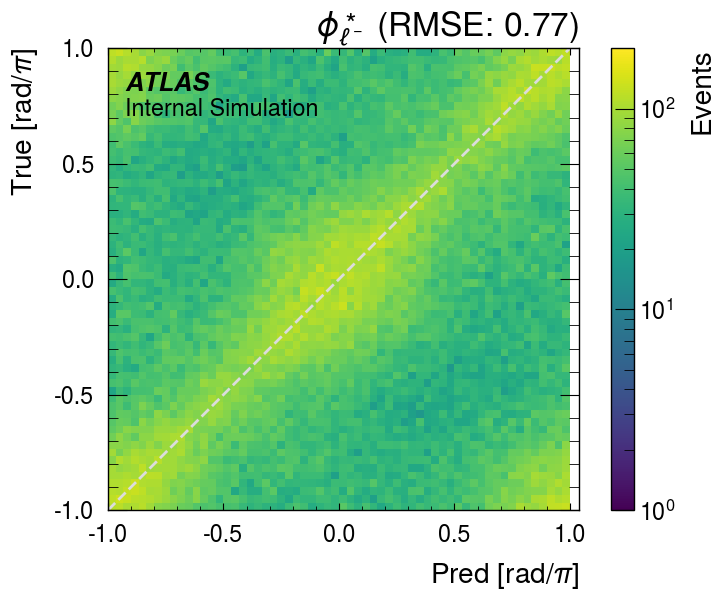

In [25]:
true_l0_phi = np.arctan2(true_l0_theta_phi[1], true_l0_theta_phi[2])
true_l1_phi = np.arctan2(true_l1_theta_phi[1], true_l1_theta_phi[2])
pred_l0_phi = np.arctan2(pred_l0_theta_phi[1], pred_l0_theta_phi[2])
pred_l1_phi = np.arctan2(pred_l1_theta_phi[1], pred_l1_theta_phi[2])

plot_1d_hist(pred_l0_phi / np.pi, true_l0_phi / np.pi, r"$\phi^\ast_{\ell^+}$", np.linspace(-1, 1, 61), unit="rad/$\pi$")
plot_2d_hist(pred_l0_phi / np.pi, true_l0_phi / np.pi, r"$\phi^\ast_{\ell^+}$", np.linspace(-1, 1, 61), log=True, unit="rad/$\pi$", color="black", vmax=2e2)
plot_1d_hist(pred_l1_phi / np.pi, true_l1_phi / np.pi, r"$\phi^\ast_{\ell^-}$", np.linspace(-1, 1, 61), unit="rad/$\pi$")
plot_2d_hist(pred_l1_phi / np.pi, true_l1_phi / np.pi, r"$\phi^\ast_{\ell^-}$", np.linspace(-1, 1, 61), log=True, unit="rad/$\pi$", color="black", vmax=2e2)

In [26]:
# sum and diff of theta
sum_theta_pred = pred_l0_theta_phi[0] + pred_l1_theta_phi[0]
sum_theta_true = true_l0_theta_phi[0] + true_l1_theta_phi[0]
diff_theta_pred = pred_l0_theta_phi[0] - pred_l1_theta_phi[0]
diff_theta_true = true_l0_theta_phi[0] - true_l1_theta_phi[0]
# plot_1d_hist(sum_theta_pred / np.pi, sum_theta_true / np.pi, r"$\sum_{+-}{\theta^\ast_{\ell}}$", np.linspace(0, 2, 51), unit="rad/$\pi$")
# plot_2d_hist(sum_theta_pred / np.pi, sum_theta_true / np.pi, r"$\sum_{+-}{\theta^\ast_{\ell}}$", np.linspace(0, 2, 51), log=True, unit="rad/$\pi$", color="black", vmax=8e2)
# plot_1d_hist(diff_theta_pred / np.pi, diff_theta_true / np.pi, r"$\Delta_{+-}\theta^\ast_{\ell}$", np.linspace(-1, 1, 61), unit="rad/$\pi$")
# plot_2d_hist(diff_theta_pred / np.pi, diff_theta_true / np.pi, r"$\Delta_{+-}\theta^\ast_{\ell}$", np.linspace(-1, 1, 61), log=True, unit="rad/$\pi$", color="black", vmax=8e2)

In [27]:
# sum and diff of phi
pred_l0_phi = np.arctan2(pred_l0_theta_phi[1], pred_l0_theta_phi[2])
true_l0_phi = np.arctan2(true_l0_theta_phi[1], true_l0_theta_phi[2])
pred_l1_phi = np.arctan2(pred_l1_theta_phi[1], pred_l1_theta_phi[2])
true_l1_phi = np.arctan2(true_l1_theta_phi[1], true_l1_theta_phi[2])
sum_phi_pred = sphi(pred_l0_phi, pred_l1_phi)
sum_phi_true = sphi(true_l0_phi, true_l1_phi)
diff_phi_pred = dphi(pred_l0_phi, pred_l1_phi)
diff_phi_true = dphi(true_l0_phi, true_l1_phi)
# plot_1d_hist(sum_phi_pred / np.pi, sum_phi_true / np.pi, r"$\sum_{+-}{\phi^\ast_{\ell}}$", np.linspace(-1, 1, 61), unit="rad/$\pi$")
# plot_2d_hist(sum_phi_pred / np.pi, sum_phi_true / np.pi, r"$\sum_{+-}{\phi^\ast_{\ell}}$", np.linspace(-1, 1, 61), log=False, unit="rad/$\pi$", color="lightgray", vmax=3e2)
# plot_1d_hist(diff_phi_pred / np.pi, diff_phi_true / np.pi, r"$\Delta_{+-}\phi^\ast_{\ell}$", np.linspace(-1, 1, 61), unit="rad/$\pi$")
# plot_2d_hist(diff_phi_pred / np.pi, diff_phi_true / np.pi, r"$\Delta_{+-}\phi^\ast_{\ell}$", np.linspace(-1, 1, 61), log=False, unit="rad/$\pi$", color="lightgray", vmax=3e2)

In [28]:
# sum of theta_phi
sum_theta_pos_phi_pos_pred = sphi(pred_l0_theta_phi[0], pred_l0_phi)
sum_theta_pos_phi_pos_true = sphi(true_l0_theta_phi[0], true_l0_phi)
sum_theta_pos_phi_neg_pred = sphi(pred_l0_theta_phi[0], pred_l1_phi)
sum_theta_pos_phi_neg_true = sphi(true_l0_theta_phi[0], true_l1_phi)
sum_theta_neg_phi_pos_pred = sphi(pred_l1_theta_phi[0], pred_l0_phi)
sum_theta_neg_phi_pos_true = sphi(true_l1_theta_phi[0], true_l0_phi)
sum_theta_neg_phi_neg_pred = sphi(pred_l1_theta_phi[0], pred_l1_phi)
sum_theta_neg_phi_neg_true = sphi(true_l1_theta_phi[0], true_l1_phi)

# plot_1d_hist(sum_theta_pos_phi_pos_pred / np.pi, sum_theta_pos_phi_pos_true / np.pi, r"$\sum_{++}{\theta^{\ast}\phi^{\ast}}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
# plot_2d_hist(sum_theta_pos_phi_pos_pred / np.pi, sum_theta_pos_phi_pos_true / np.pi, r"$\sum_{++}{\theta^{\ast}\phi^{\ast}}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=8e2)
# plot_1d_hist(sum_theta_pos_phi_neg_pred / np.pi, sum_theta_pos_phi_neg_true / np.pi, r"$\sum_{+-}{\theta^{\ast}\phi^{\ast}}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
# plot_2d_hist(sum_theta_pos_phi_neg_pred / np.pi, sum_theta_pos_phi_neg_true / np.pi, r"$\sum_{+-}{\theta^{\ast}\phi^{\ast}}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=8e2)
# plot_1d_hist(sum_theta_neg_phi_pos_pred / np.pi, sum_theta_neg_phi_pos_true / np.pi, r"$\sum_{--}{\theta^{\ast}\phi^{\ast}}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
# plot_2d_hist(sum_theta_neg_phi_pos_pred / np.pi, sum_theta_neg_phi_pos_true / np.pi, r"$\sum_{--}{\theta^{\ast}\phi^{\ast}}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=8e2)
# plot_1d_hist(sum_theta_neg_phi_neg_pred / np.pi, sum_theta_neg_phi_neg_true / np.pi, r"$\sum_{--}{\theta^{\ast}\phi^{\ast}}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
# plot_2d_hist(sum_theta_neg_phi_neg_pred / np.pi, sum_theta_neg_phi_neg_true / np.pi, r"$\sum_{--}{\theta^{\ast}\phi^{\ast}}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=8e2)

In [29]:
# diff of theta_phi
diff_theta_pos_phi_pos_pred = dphi(pred_l0_theta_phi[0], pred_l0_phi)
diff_theta_pos_phi_pos_true = dphi(true_l0_theta_phi[0], true_l0_phi)
diff_theta_pos_phi_neg_pred = dphi(pred_l0_theta_phi[0], pred_l1_phi)
diff_theta_pos_phi_neg_true = dphi(true_l0_theta_phi[0], true_l1_phi)
diff_theta_neg_phi_pos_pred = dphi(pred_l1_theta_phi[0], pred_l0_phi)
diff_theta_neg_phi_pos_true = dphi(true_l1_theta_phi[0], true_l0_phi)
diff_theta_neg_phi_neg_pred = dphi(pred_l1_theta_phi[0], pred_l1_phi)
diff_theta_neg_phi_neg_true = dphi(true_l1_theta_phi[0], true_l1_phi)

# plot_1d_hist(diff_theta_pos_phi_pos_pred / np.pi, diff_theta_pos_phi_pos_true / np.pi, r"$\Delta_{++}{\theta^{\ast}\phi^{\ast}}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
# plot_2d_hist(diff_theta_pos_phi_pos_pred / np.pi, diff_theta_pos_phi_pos_true / np.pi, r"$\Delta_{++}{\theta^{\ast}\phi^{\ast}}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=8e2)
# plot_1d_hist(diff_theta_pos_phi_neg_pred / np.pi, diff_theta_pos_phi_neg_true / np.pi, r"$\Delta_{+-}{\theta^{\ast}\phi^{\ast}}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
# plot_2d_hist(diff_theta_pos_phi_neg_pred / np.pi, diff_theta_pos_phi_neg_true / np.pi, r"$\Delta_{+-}{\theta^{\ast}\phi^{\ast}}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=8e2)
# plot_1d_hist(diff_theta_neg_phi_pos_pred / np.pi, diff_theta_neg_phi_pos_true / np.pi, r"$\Delta_{--}{\theta^{\ast}\phi^{\ast}}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
# plot_2d_hist(diff_theta_neg_phi_pos_pred / np.pi, diff_theta_neg_phi_pos_true / np.pi, r"$\Delta_{--}{\theta^{\ast}\phi^{\ast}}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=8e2)
# plot_1d_hist(diff_theta_neg_phi_neg_pred / np.pi, diff_theta_neg_phi_neg_true / np.pi, r"$\Delta_{--}{\theta^{\ast}\phi^{\ast}}$", np.linspace(0, 1, 51), unit="rad/$\pi$")
# plot_2d_hist(diff_theta_neg_phi_neg_pred / np.pi, diff_theta_neg_phi_neg_true / np.pi, r"$\Delta_{--}{\theta^{\ast}\phi^{\ast}}$", np.linspace(0, 1, 51), log=True, unit="rad/$\pi$", color="black", vmax=8e2)

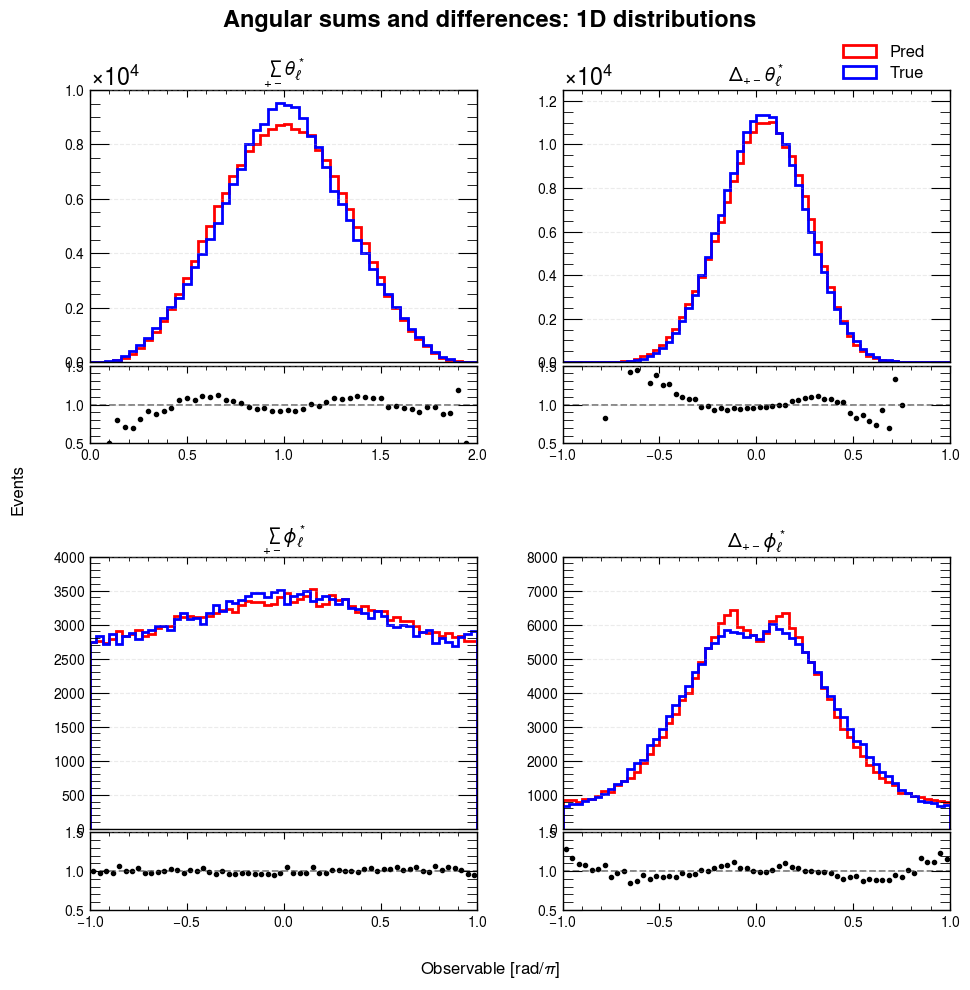

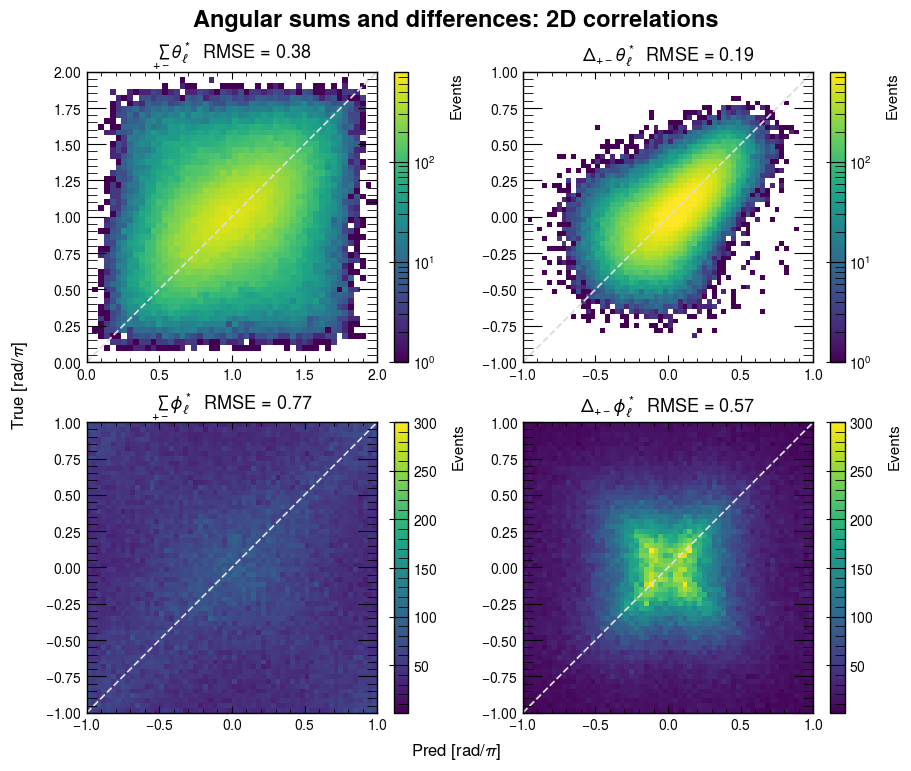

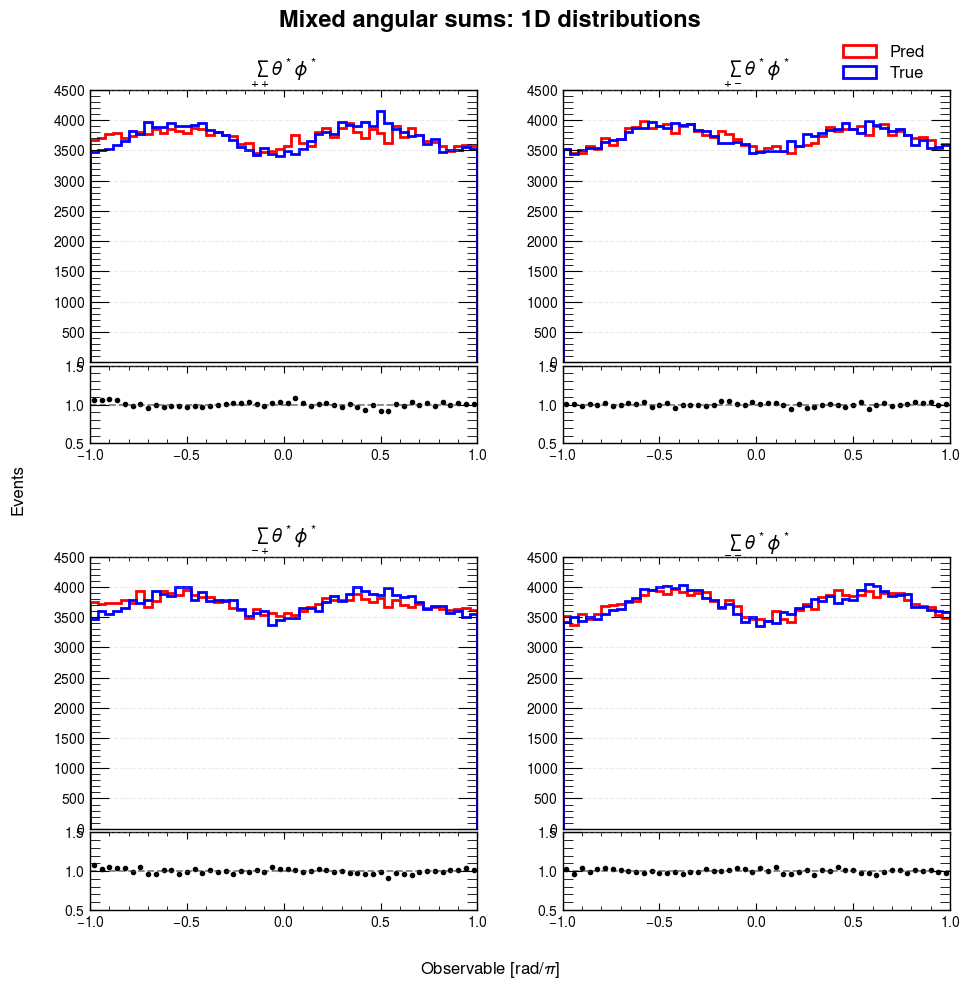

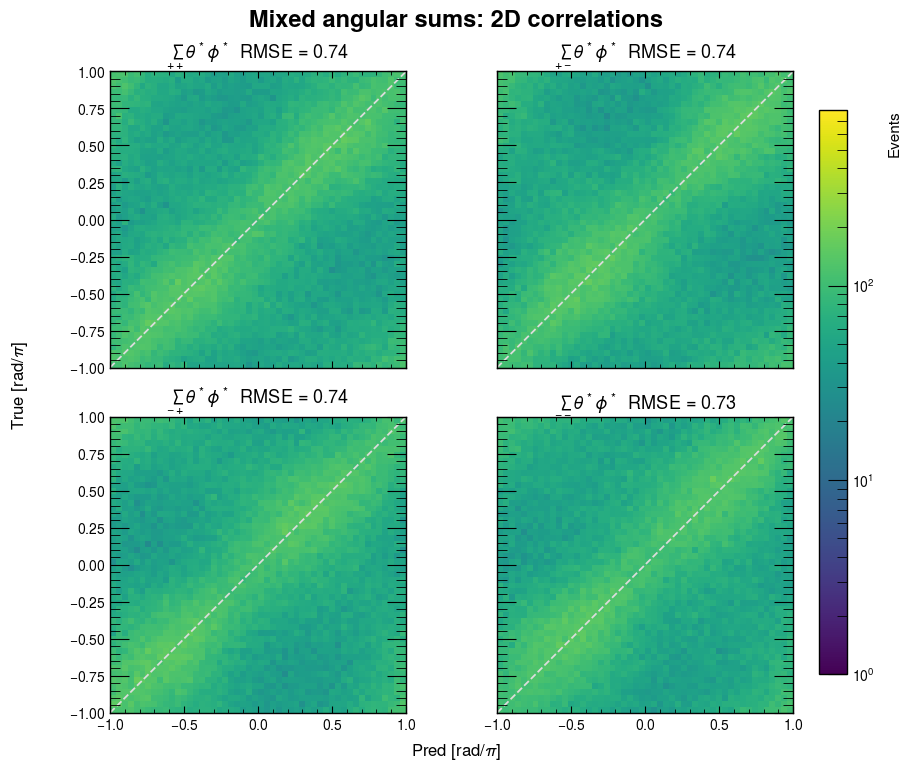

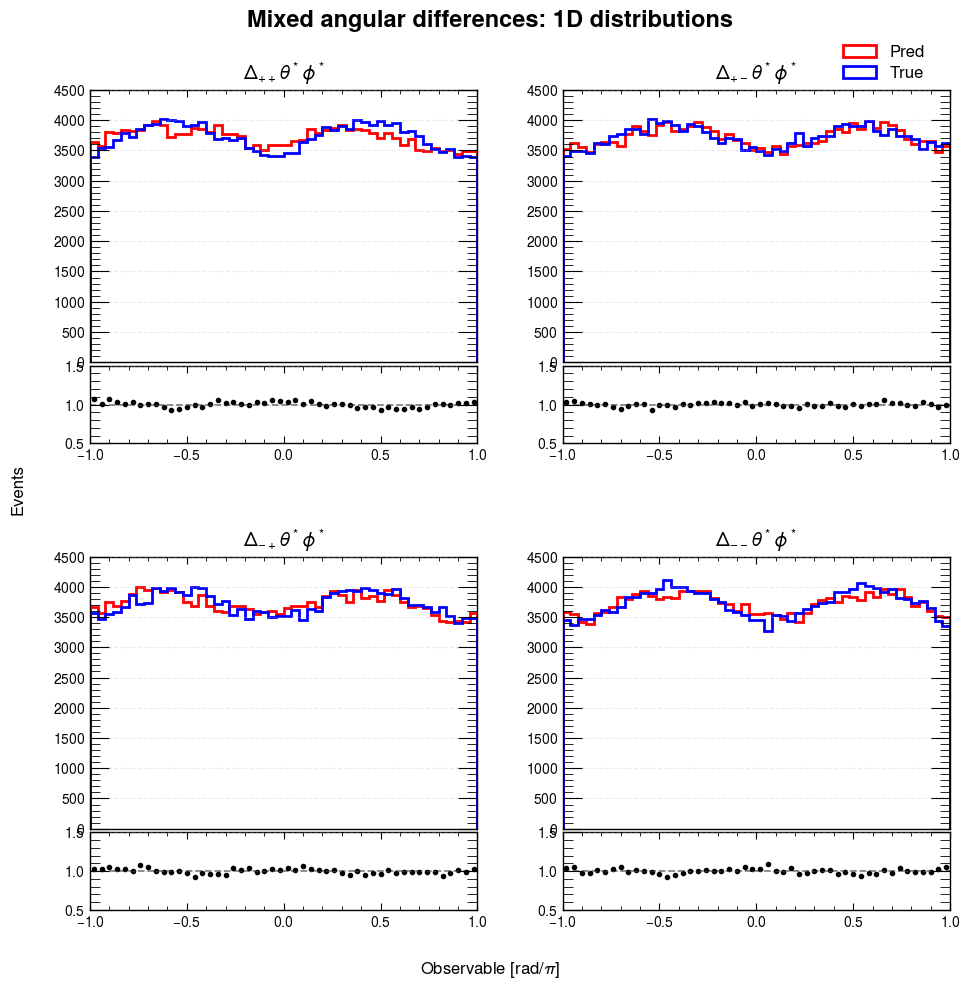

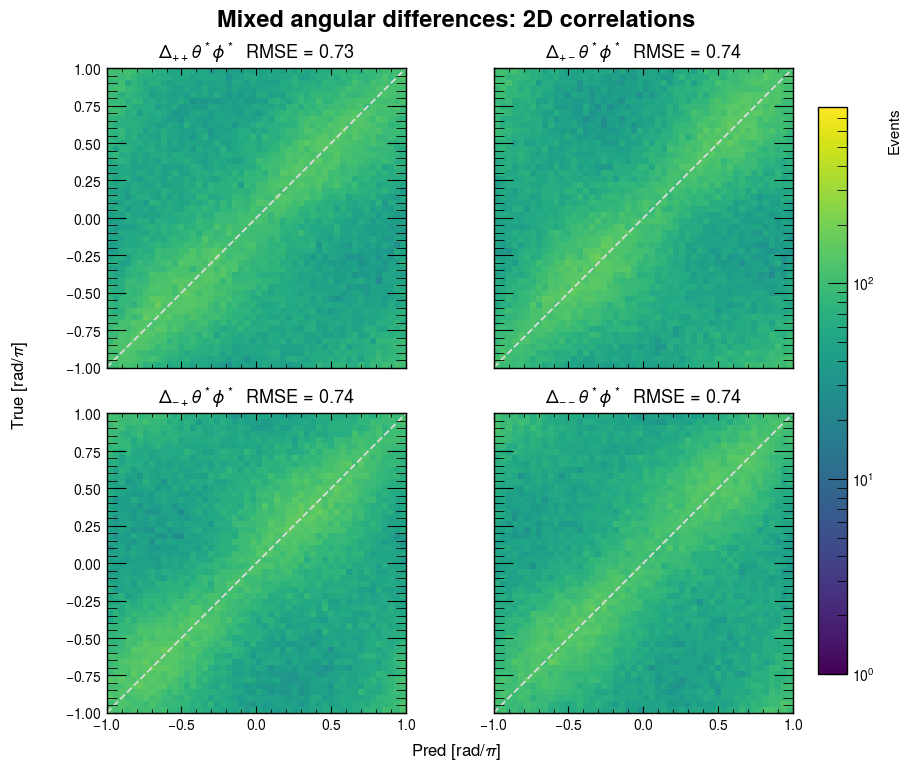

In [30]:
angular_observables = [
    {"pred": sum_theta_pred, "truth": sum_theta_true, "label": r"$\sum_{+-}\theta^*_{\ell}$", "bins": np.linspace(0, 2, 51), "log": True, "vmax": 8e2},
    {"pred": diff_theta_pred, "truth": diff_theta_true, "label": r"$\Delta_{+-}\theta^*_{\ell}$", "bins": np.linspace(-1, 1, 61), "log": True, "vmax": 8e2},
    {"pred": sum_phi_pred, "truth": sum_phi_true, "label": r"$\sum_{+-}\phi^*_{\ell}$", "bins": np.linspace(-1, 1, 61), "log": False, "vmax": 3e2},
    {"pred": diff_phi_pred, "truth": diff_phi_true, "label": r"$\Delta_{+-}\phi^*_{\ell}$", "bins": np.linspace(-1, 1, 61), "log": False, "vmax": 3e2},
]

mixed_sum_observables = [
    {"pred": sum_theta_pos_phi_pos_pred, "truth": sum_theta_pos_phi_pos_true, "label": r"$\sum_{++}\theta^*\phi^*$", "bins": np.linspace(-1, 1, 51), "log": True, "vmax": 8e2},
    {"pred": sum_theta_pos_phi_neg_pred, "truth": sum_theta_pos_phi_neg_true, "label": r"$\sum_{+-}\theta^*\phi^*$", "bins": np.linspace(-1, 1, 51), "log": True, "vmax": 8e2},
    {"pred": sum_theta_neg_phi_pos_pred, "truth": sum_theta_neg_phi_pos_true, "label": r"$\sum_{-+}\theta^*\phi^*$", "bins": np.linspace(-1, 1, 51), "log": True, "vmax": 8e2},
    {"pred": sum_theta_neg_phi_neg_pred, "truth": sum_theta_neg_phi_neg_true, "label": r"$\sum_{--}\theta^*\phi^*$", "bins": np.linspace(-1, 1, 51), "log": True, "vmax": 8e2},
]

mixed_diff_observables = [
    {"pred": diff_theta_pos_phi_pos_pred, "truth": diff_theta_pos_phi_pos_true, "label": r"$\Delta_{++}\theta^*\phi^*$", "bins": np.linspace(-1, 1, 51), "log": True, "vmax": 8e2},
    {"pred": diff_theta_pos_phi_neg_pred, "truth": diff_theta_pos_phi_neg_true, "label": r"$\Delta_{+-}\theta^*\phi^*$", "bins": np.linspace(-1, 1, 51), "log": True, "vmax": 8e2},
    {"pred": diff_theta_neg_phi_pos_pred, "truth": diff_theta_neg_phi_pos_true, "label": r"$\Delta_{-+}\theta^*\phi^*$", "bins": np.linspace(-1, 1, 51), "log": True, "vmax": 8e2},
    {"pred": diff_theta_neg_phi_neg_pred, "truth": diff_theta_neg_phi_neg_true, "label": r"$\Delta_{--}\theta^*\phi^*$", "bins": np.linspace(-1, 1, 51), "log": True, "vmax": 8e2},
]

angular_1d_fig, angular_1d_axes = plot_angular_1d_grid(angular_observables, "Angular sums and differences: 1D distributions")
angular_2d_fig, angular_2d_axes = plot_angular_2d_grid(angular_observables, "Angular sums and differences: 2D correlations")
mixed_sum_1d_fig, mixed_sum_1d_axes = plot_angular_1d_grid(mixed_sum_observables, "Mixed angular sums: 1D distributions", share_axes=True)
mixed_sum_2d_fig, mixed_sum_2d_axes = plot_angular_2d_grid(mixed_sum_observables, "Mixed angular sums: 2D correlations", shared_colorbar=True, share_axes=True)
mixed_diff_1d_fig, mixed_diff_1d_axes = plot_angular_1d_grid(mixed_diff_observables, "Mixed angular differences: 1D distributions", share_axes=True)
mixed_diff_2d_fig, mixed_diff_2d_axes = plot_angular_2d_grid(mixed_diff_observables, "Mixed angular differences: 2D correlations", shared_colorbar=True, share_axes=True)

Using metrics file: /root/work/ww-pcres/meta/logs/version_0/metrics.csv
Best loss values at best epoch (min val_loss):
  total: loss=9.24761 val_loss=8.18291
  Std $W$ 4-vec Huber: train=0.145114 val=0.144413 weighted_train=4.35342 weighted_val=4.3324
  $m_H$ Huber: train=0.36435 val=0.247419 weighted_train=3.6435 weighted_val=2.47419
  Joint $m_W$ MMD: train=0.00376606 val=0.00293489 weighted_train=0.376606 weighted_val=0.293489
  $m_W$ Huber: train=0.0573199 val=0.0572645 weighted_train=0.11464 weighted_val=0.114529
  Angular MMD: train=2.55544e-05 val=4.66231e-05 weighted_train=0.255544 weighted_val=0.466231
  $\Delta \mathrm{MET}$: train=0.335928 val=0.334711 weighted_train=0.503892 weighted_val=0.502067
Unavailable train/validation pairs: $\alpha$ MMD


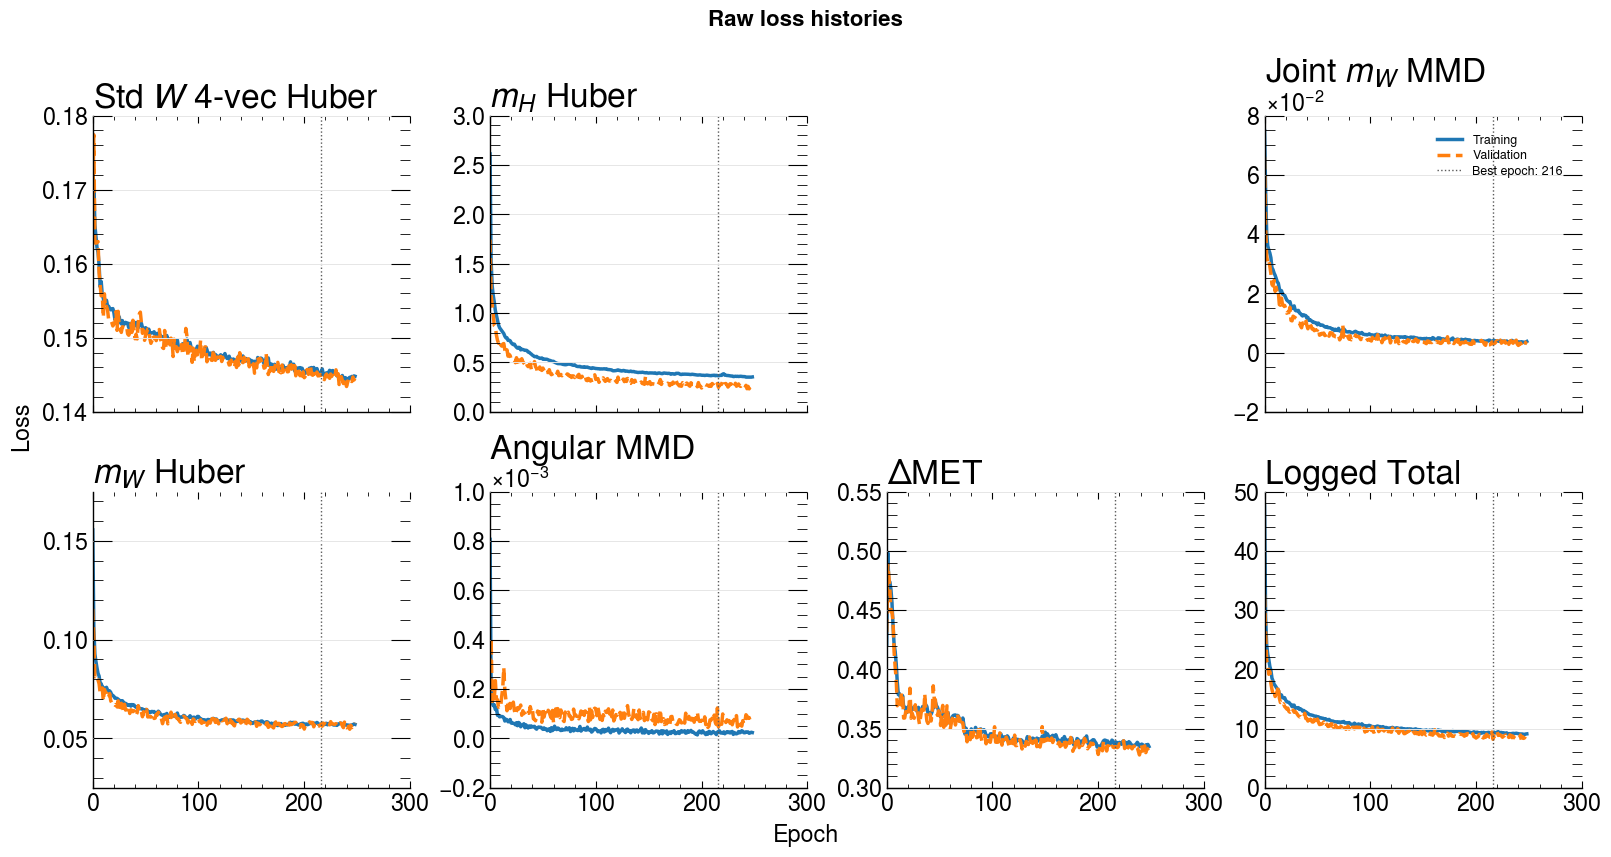

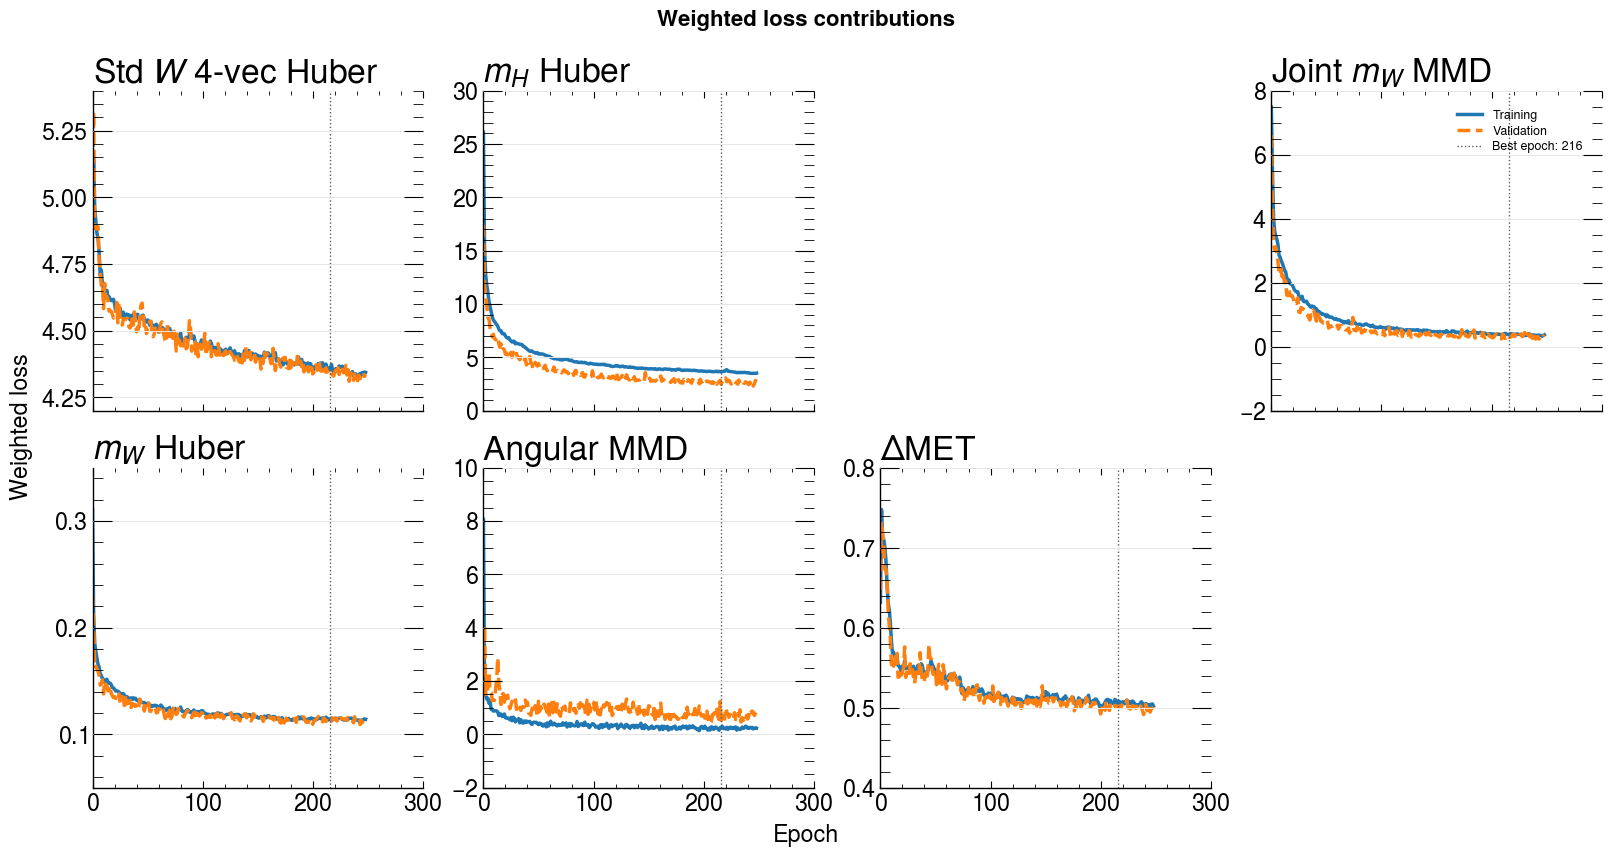

No populated pairwise grad_cos metrics found.


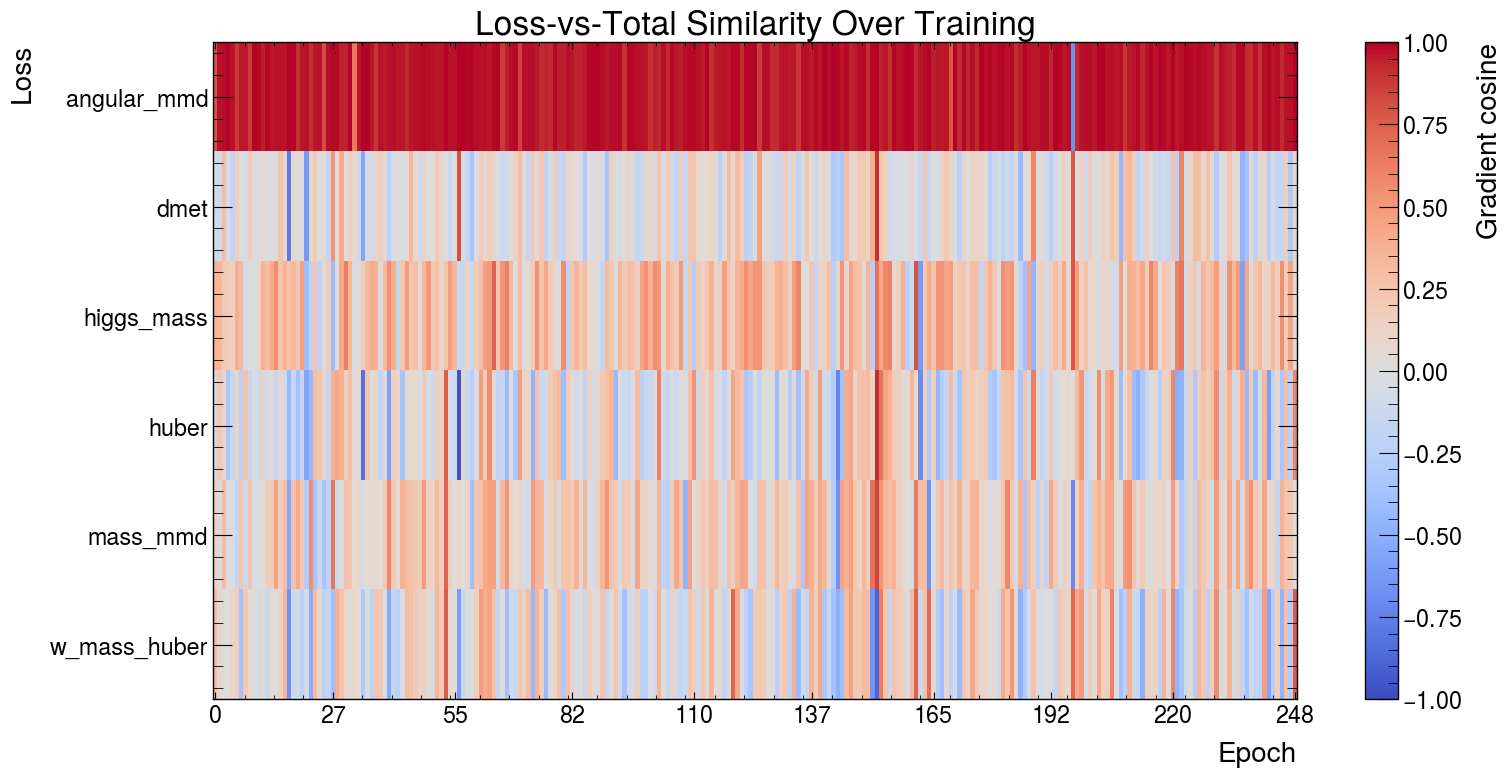

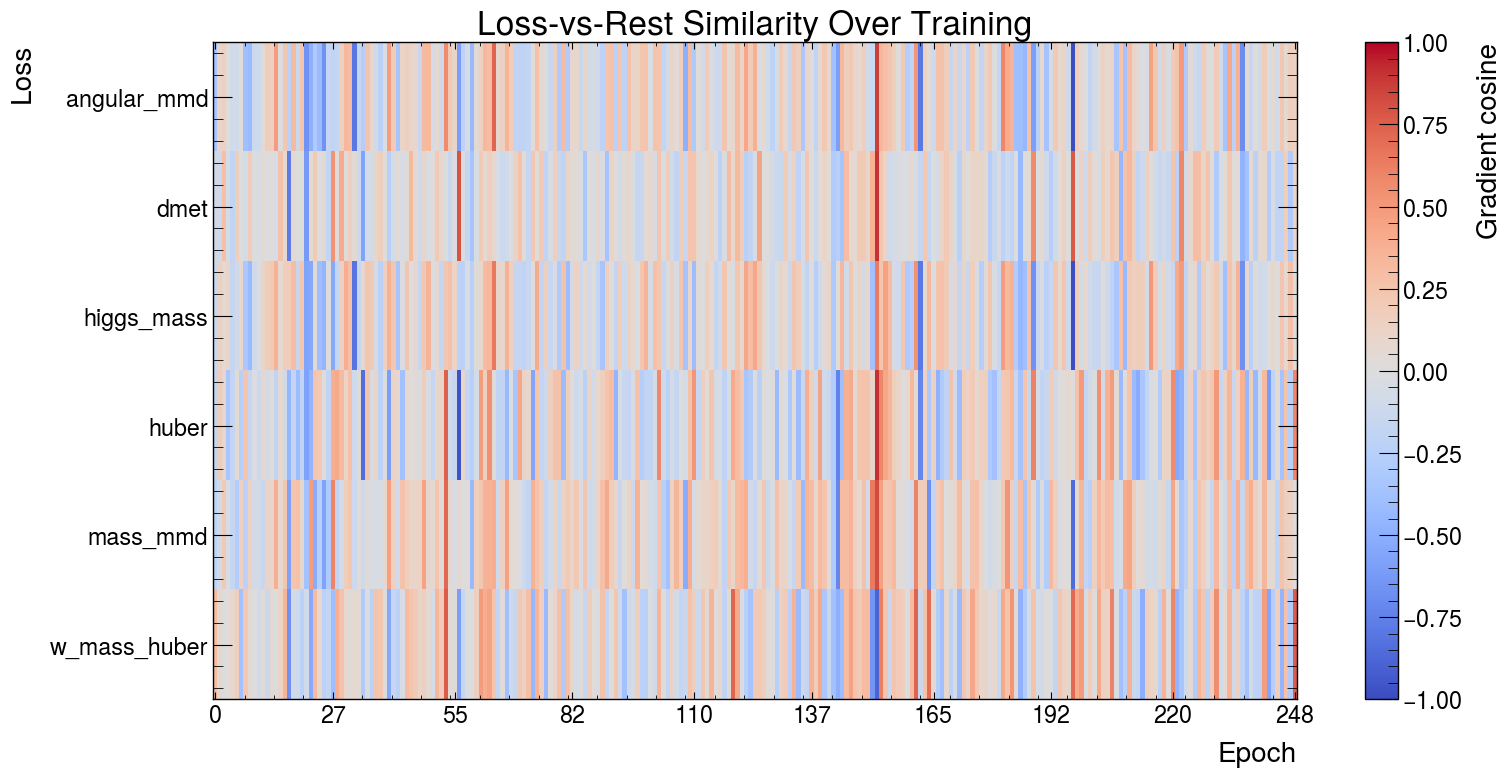

Visualized 0 pairwise, 6 total, and 6 rest grad_cos metrics across 249 logged rows.


In [31]:
# training history

if "LOG_DIR" not in globals():
    log_dirs = sorted(
        (RUN_DIR / "logs").glob("version_*"),
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )
    LOG_DIR = log_dirs[0] if log_dirs else None

if LOG_DIR is None:
    print("No logs found.")
else:
    loss_diagnostics = plot_loss_curves(LOG_DIR / "metrics.csv", cfg)


metrics_path = LOG_DIR / "metrics.csv"
plot_gradient_cosine_heatmaps(pd.read_csv(metrics_path))

In [32]:
# import shap
# import numpy as np
# import matplotlib as mpl
# from matplotlib import pyplot as plt

# mpl.rcParams.update(mpl.rcParamsDefault)

# # Feature order follows load_data.py train_obj construction.
# feature_names = [
#     "lep+ px", "lep+ py", "lep+ pz", "lep+ energy",
#     "lep- px", "lep- py", "lep- pz", "lep- energy",
#     "jet1 px", "jet1 py", "jet1 pz", "jet1 energy",
#     "jet2 px", "jet2 py", "jet2 pz", "jet2 energy",
#     "MET px", "MET py",
#     "m_ll", "delta eta ll", "delta phi ll", "delta phi ll-MET"
# ]

# output_names = [
#     "W+ px", "W+ py", "W+ pz", "W+ energy [GeV]",
#     "W- px", "W- py", "W- pz", "W- energy [GeV]",
# ]

# background_sample = torch.tensor(train_features[0:256]).float().to(device)
# samples_to_explain = torch.tensor(train_features[512:512+1024]).float().to(device)
# x_explain = samples_to_explain.detach().cpu().numpy()

# if len(feature_names) != x_explain.shape[1]:
#     raise ValueError(f"Expected {len(feature_names)} features, got {x_explain.shape[1]}")

# explainer = shap.GradientExplainer(model, background_sample)
# shap_values = explainer.shap_values(samples_to_explain, nsamples=200)

# if isinstance(shap_values, list):
#     shap_values = np.stack(shap_values, axis=-1)

# importance_by_output = np.abs(shap_values).mean(axis=0)
# overall_importance = importance_by_output.mean(axis=1)
# top_overall = np.argsort(overall_importance)[::-1][:20]

# plt.figure(figsize=(9, 7))
# plt.barh(
#     [feature_names[idx] for idx in top_overall[::-1]],
#     overall_importance[top_overall[::-1]],
# )
# plt.xlabel("Mean |SHAP value| across outputs")
# plt.title("Overall SHAP Feature Importance", fontsize=15)
# plt.tight_layout()
# plt.show()

# heatmap_features = top_overall[::-1]
# plt.figure(figsize=(10, 8))
# plt.imshow(importance_by_output[heatmap_features], aspect="auto", cmap="viridis")
# plt.colorbar(label="Mean |SHAP value|")
# plt.yticks(range(len(heatmap_features)), [feature_names[idx] for idx in heatmap_features])
# plt.xticks(
#     range(min(len(output_names), importance_by_output.shape[1])),
#     output_names[:importance_by_output.shape[1]],
#     rotation=45,
#     ha="right",
# )
# plt.title("SHAP Importance by Feature and Output", fontsize=15)
# plt.tight_layout()
# plt.show()

# for i in range(shap_values.shape[-1]):
#     values = shap_values[:, :, i]
#     importance = importance_by_output[:, i]
#     top = np.argsort(importance)[::-1][:15]
#     output_label = output_names[i] if i < len(output_names) else f"output {i}"

#     print(f"Top features for {output_label}:")
#     for rank, idx in enumerate(top, start=1):
#         print(f"  {rank:2d}. {feature_names[idx]}: {importance[idx]:.6f}")

#     shap.summary_plot(
#         values,
#         x_explain,
#         feature_names=feature_names,
#         plot_type="bar",
#         max_display=15,
#         show=False,
#     )
#     plt.title(f"SHAP Feature Importance: {output_label}", fontsize=15)
#     plt.tight_layout()
#     plt.show()

#     shap.summary_plot(
#         values,
#         x_explain,
#         feature_names=feature_names,
#         plot_type="dot",
#         max_display=15,
#         show=False,
#     )
#     plt.title(f"SHAP Beeswarm: {output_label}", fontsize=15)
#     plt.tight_layout()
#     plt.show()

In [33]:
from scipy.stats import ks_2samp


def _alpha(x_batch, w4):
    w = w4[..., :8].reshape(-1, 2, 4)
    nu0 = w[:, 0] - x_batch[..., :4]
    nu1 = w[:, 1] - x_batch[..., 4:8]
    p0 = np.linalg.norm(nu0[..., :3], axis=-1)
    p1 = np.linalg.norm(nu1[..., :3], axis=-1)
    tot = p0 + p1
    frac = np.where(tot == 0, 0.5, p0 / np.where(tot == 0, 1.0, tot))
    return 2.0 * frac - 1.0


def _w_masses(w4):
    w = w4[..., :8].reshape(-1, 2, 4).reshape(-1, 4)
    m2 = w[..., 3] ** 2 - w[..., 0] ** 2 - w[..., 1] ** 2 - w[..., 2] ** 2
    return np.sqrt(np.clip(m2, 1e-6, None))


def _higgs_mass(w4):
    s = w4[..., :8].reshape(-1, 2, 4).sum(1)
    m2 = s[..., 3] ** 2 - s[..., 0] ** 2 - s[..., 1] ** 2 - s[..., 2] ** 2
    return np.sqrt(np.clip(m2, 1e-6, None))


alpha_ks = ks_2samp(_alpha(train_features, predictions),
                    _alpha(train_features, true_labels)).statistic
mw_ks = ks_2samp(_w_masses(predictions), _w_masses(true_labels)).statistic

pred_mh = _higgs_mass(predictions)
true_mh = _higgs_mass(true_labels)
within2 = 100.0 * np.mean(np.abs(pred_mh - 125.0) < 2.0)
within5 = 100.0 * np.mean(np.abs(pred_mh - 125.0) < 5.0)

print("Distribution-faithfulness and delta-like-mH summary:")
print(f"  events          : {len(true_labels)}")
print(f"  alpha KS        : {alpha_ks:.4f}   (lower = more faithful)")
print(f"  W-mass KS       : {mw_ks:.4f}   (lower = more faithful)")
print(f"  predicted mH    : mean {pred_mh.mean():.2f} GeV, std {pred_mh.std():.2f} GeV")
print(f"  mH within 2 GeV : {within2:.1f}%")
print(f"  mH within 5 GeV : {within5:.1f}%")
print(f"  |pred - truth|  : {np.abs(pred_mh - true_mh).mean():.2f} GeV")

Distribution-faithfulness and delta-like-mH summary:
  events          : 185968
  alpha KS        : 0.1595   (lower = more faithful)
  W-mass KS       : 0.0891   (lower = more faithful)
  predicted mH    : mean 125.59 GeV, std 4.44 GeV
  mH within 2 GeV : 59.3%
  mH within 5 GeV : 88.8%
  |pred - truth|  : 2.46 GeV
